# Hybrid-system identification with Morse graph validation

This notebook implements a complete pipeline for hybrid dynamical system identification
and topological validation on a **4D bistable network**.

## System

Four nodes, each with 1D bistable dynamics $g(x_i, \mu_i) = \mu_i x_i - x_i^3$,
coupled on a graph. There are $R = 4$ modes, each with its own graph, coupling, and
bifurcation parameters.

## Switching

- **Sections 1--9 (identification)**: piecewise-constant random mode sequences
  (externally imposed, as in the original Sprott notebook).
- **Section 10 (Morse graph analysis)**: state-dependent switching via polynomial guards
  $p_1(x) = x_1 + x_2$, $p_2(x) = x_3 + x_4$, using `SwitchingSystem`.

## Tracks

- **Track A (physics-informed)**: known local dynamics family, learns per-mode $W$, $\mu$, $\alpha$, $\beta$.
  Supervised DHAL selector.
- **Track B (reduced-structure)**: shared + per-mode residual MLPs replacing exact dynamics.
  Unsupervised DHAL selector.

## 0. Imports and runtime setup

In [1]:
import itertools
import sys
import os
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, os.path.join(os.getcwd(), 'MorseGraph-L4DC'))

from MorseGraphL4DC.grids import UniformGrid
from MorseGraphL4DC.dynamics import F_data
from MorseGraphL4DC.systems import SwitchingSystem
from MorseGraphL4DC.analysis import full_morse_graph_analysis
from MorseGraphL4DC.metrics import compute_all_metrics

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

device = torch.device("mps" if torch.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


## 1. True hybrid simulator

### Mathematical formulation

There are $R = 4$ modes.  Each mode $r$ contains:
- graph $W^{(r)} \in \mathbb{R}^{4 \times 4}$,
- gains $(\alpha^{(r)}, \beta^{(r)})$,
- bifurcation parameter vector $\mu^{(r)} \in \mathbb{R}^4$.

**Local dynamics** (1D bistable per node):
$$g(x_i, \mu_i) = \mu_i x_i - x_i^3$$

**Coupling** (mode $r$):
$$\dot x = g(x, \mu^{(r)}) + \alpha^{(r)} D(W^{(r)}) x + \beta^{(r)} W^{(r)} x, \quad x \in \mathbb{R}^4$$

A piecewise-constant mode sequence $z_k \in \{0,1,2,3\}$ selects which mode is active at each time step.

Mode 0: alpha=0.05, beta=-0.05, mu=[1. 1. 1. 1.]
  A =
[[0 1 1 1]
 [1 0 1 0]
 [1 1 0 1]
 [1 0 1 0]]
Mode 1: alpha=0.08, beta=-0.04, mu=[0.8 0.6 0.8 0.6]
  A =
[[0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]
 [1 0 1 0]]
Mode 2: alpha=0.06, beta=-0.06, mu=[0.6 0.8 0.6 0.8]
  A =
[[0 1 1 1]
 [1 0 1 1]
 [1 1 0 1]
 [1 1 1 0]]
Mode 3: alpha=0.1, beta=-0.03, mu=[0.5 0.5 0.5 0.5]
  A =
[[0 1 1 1]
 [1 0 1 1]
 [1 1 0 1]
 [1 1 1 0]]


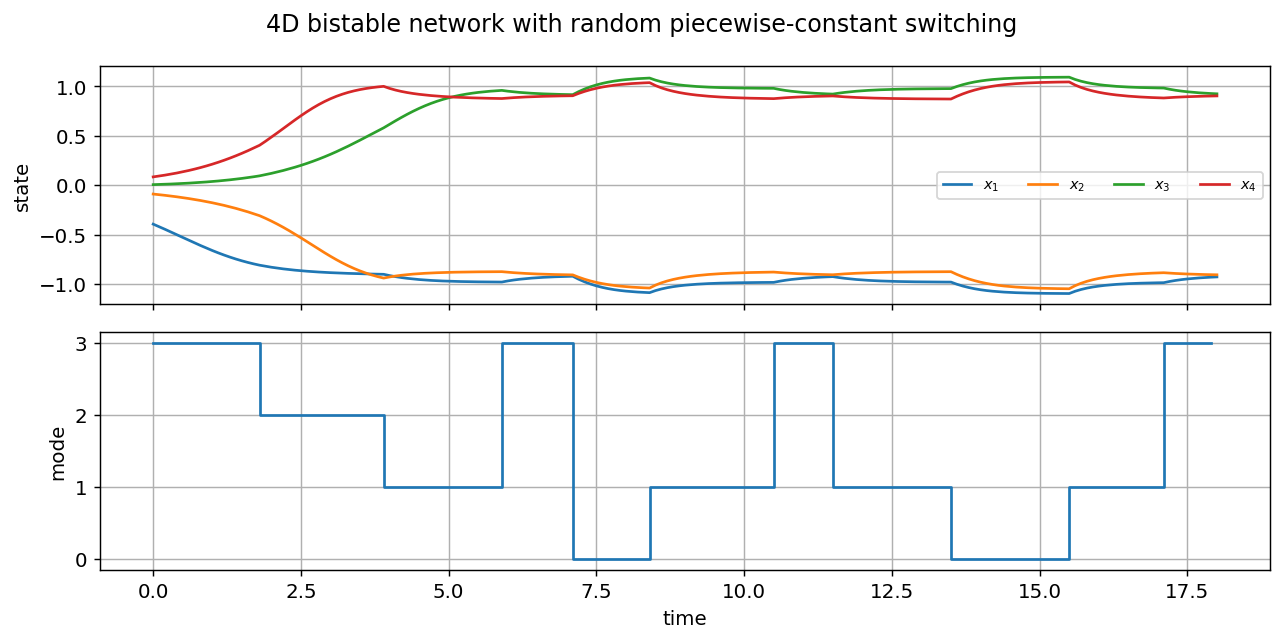

In [2]:
# ---- Adjacency matrices ----
A0 = np.array([[0,1,1,1],[1,0,1,0],[1,1,0,1],[1,0,1,0]], dtype=float)
A1 = np.array([[0,1,0,1],[1,0,1,0],[0,1,0,1],[1,0,1,0]], dtype=float)
A2 = np.array([[0,1,1,1],[1,0,1,1],[1,1,0,1],[1,1,1,0]], dtype=float)

# ---- Mode parameters (4 modes) ----
bistable_mode_params = [
    {"A": A0, "mu": np.array([1.0, 1.0, 1.0, 1.0]), "alpha":  0.05, "beta": -0.05},
    {"A": A1, "mu": np.array([0.8, 0.6, 0.8, 0.6]), "alpha":  0.08, "beta": -0.04},
    {"A": A2, "mu": np.array([0.6, 0.8, 0.6, 0.8]), "alpha":  0.06, "beta": -0.06},
    {"A": A2, "mu": np.array([0.5, 0.5, 0.5, 0.5]), "alpha":  0.10, "beta": -0.03},
]

# ---- Polynomial guards (used only in Section 10 for Morse graph analysis) ----
bistable_polynomials = [
    lambda x: x[0] + x[1],
    lambda x: x[2] + x[3],
]

def make_bistable_vf(A, mu, alpha, beta):
    """Create bistable network vector field closure."""
    deg = A.sum(axis=1)
    def vf(x):
        return mu * x - x**3 + alpha * deg * x + beta * A @ x
    return vf

bistable_vfs = [make_bistable_vf(**m) for m in bistable_mode_params]

# SwitchingSystem for Section 10 Morse graph analysis
bistable_system = SwitchingSystem(bistable_polynomials, bistable_vfs)

num_modes = 4

# ---- ODE right-hand side for a fixed mode ----
def network_rhs_bistable(t, x, mode):
    A = mode["A"]; mu = mode["mu"]; alpha = mode["alpha"]; beta = mode["beta"]
    deg = A.sum(axis=1)
    return mu * x - x**3 + alpha * deg * x + beta * A @ x

# ---- Random piecewise-constant mode sequence ----
def random_switch_sequence(num_steps, num_modes, min_dwell=6, max_dwell=18, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    modes = []
    current = int(rng.integers(0, num_modes))
    while len(modes) < num_steps:
        dwell = int(rng.integers(min_dwell, max_dwell + 1))
        modes.extend([current] * dwell)
        choices = [m for m in range(num_modes) if m != current]
        current = int(rng.choice(choices))
    return np.array(modes[:num_steps], dtype=int)

# ---- Simulate trajectory under a given mode sequence ----
def simulate_hybrid_switched_trajectory(x0, mode_seq, dt_val, mode_bank):
    x = x0.copy()
    states = [x.copy()]
    for z in mode_seq:
        mode = mode_bank[int(z)]
        sol = solve_ivp(
            lambda t, y: network_rhs_bistable(t, y, mode),
            (0.0, dt_val), x, t_eval=[dt_val],
            rtol=1e-8, atol=1e-10, max_step=dt_val / 5.0,
        )
        x = sol.y[:, -1]
        states.append(x.copy())
    return np.stack(states, axis=0)

for k, m in enumerate(bistable_mode_params):
    print(f"Mode {k}: alpha={m['alpha']}, beta={m['beta']}, mu={m['mu']}")
    print(f"  A =\n{m['A'].astype(int)}")

# ---- Demo trajectory ----
dt = 0.1
rng_demo = np.random.default_rng(7)
z_demo = random_switch_sequence(180, num_modes, min_dwell=10, max_dwell=22, rng=rng_demo)
x0_demo = rng_demo.uniform(-0.8, 0.8, size=4)
traj_demo = simulate_hybrid_switched_trajectory(x0_demo, z_demo, dt, bistable_mode_params)

t_demo = np.arange(traj_demo.shape[0]) * dt
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for i in range(4):
    axes[0].plot(t_demo, traj_demo[:, i], label=f'$x_{i+1}$')
axes[0].set_ylabel('state')
axes[0].legend(ncol=4, fontsize=8)
axes[1].step(t_demo[:-1], z_demo, where='post')
axes[1].set_ylabel('mode')
axes[1].set_xlabel('time')
fig.suptitle('4D bistable network with random piecewise-constant switching')
plt.tight_layout()
plt.show()

## 2. Dataset construction

### Goal
Build one-step prediction pairs $(X_k, X_{k+1})$ with mode labels $z_k$
and history windows $X_{k-h:k}$ from trajectories under random piecewise-constant mode switching.

History windows are normalized for the GRU selector.

In [3]:
history_len = 12

def build_hybrid_dataset(num_traj=100, steps_per_traj=200, history_len=12,
                         init_scale=0.8, min_dwell=6, max_dwell=18, seed=0):
    rng = np.random.default_rng(seed)
    X_list, Y_list, Z_list, H_list = [], [], [], []
    for _ in range(num_traj):
        x0 = rng.uniform(-init_scale, init_scale, size=4)
        z = random_switch_sequence(steps_per_traj, num_modes,
                                   min_dwell=min_dwell, max_dwell=max_dwell, rng=rng)
        traj = simulate_hybrid_switched_trajectory(x0, z, dt, bistable_mode_params)
        for k in range(history_len - 1, steps_per_traj):
            H_list.append(traj[k - history_len + 1:k + 1])
            X_list.append(traj[k])
            Y_list.append(traj[k + 1])
            Z_list.append(z[k])
    return np.stack(X_list), np.stack(Y_list), np.array(Z_list), np.stack(H_list)

X_all, Y_all, Z_all, H_all = build_hybrid_dataset(history_len=history_len)

perm = np.random.default_rng(123).permutation(X_all.shape[0])
n_train = int(0.8 * X_all.shape[0])
train_idx, test_idx = perm[:n_train], perm[n_train:]

X_train, X_test = X_all[train_idx], X_all[test_idx]
Y_train, Y_test = Y_all[train_idx], Y_all[test_idx]
Z_train, Z_test = Z_all[train_idx], Z_all[test_idx]
H_train, H_test = H_all[train_idx], H_all[test_idx]

x_mean = X_train.mean(axis=0)    # (4,)
x_std  = X_train.std(axis=0) + 1e-6  # (4,)

def norm_hist(H):
    return (H - x_mean[None, None, :]) / x_std[None, None, :]

H_train_n = norm_hist(H_train)
H_test_n  = norm_hist(H_test)

sup_train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                             torch.tensor(Y_train, dtype=torch.float32),
                             torch.tensor(Z_train, dtype=torch.long))
sup_test_ds  = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                             torch.tensor(Y_test, dtype=torch.float32),
                             torch.tensor(Z_test, dtype=torch.long))
lat_train_ds = TensorDataset(torch.tensor(H_train_n, dtype=torch.float32),
                             torch.tensor(X_train, dtype=torch.float32),
                             torch.tensor(Y_train, dtype=torch.float32),
                             torch.tensor(Z_train, dtype=torch.long))
lat_test_ds  = TensorDataset(torch.tensor(H_test_n, dtype=torch.float32),
                             torch.tensor(X_test, dtype=torch.float32),
                             torch.tensor(Y_test, dtype=torch.float32),
                             torch.tensor(Z_test, dtype=torch.long))

sup_train_loader = DataLoader(sup_train_ds, batch_size=256, shuffle=True)
sup_test_loader  = DataLoader(sup_test_ds,  batch_size=512, shuffle=False)
lat_train_loader = DataLoader(lat_train_ds, batch_size=256, shuffle=True)
lat_test_loader  = DataLoader(lat_test_ds,  batch_size=512, shuffle=False)

print("Train size:", len(sup_train_ds), "Test size:", len(sup_test_ds))
print("Train mode counts:", np.bincount(Z_train, minlength=num_modes))
print("State range:", np.round(X_all.min(axis=0), 3), "to", np.round(X_all.max(axis=0), 3))

Train size: 15120 Test size: 3780
Train mode counts: [3605 4006 3666 3843]
State range: [-1.134 -1.091 -1.133 -1.093] to [1.133 1.094 1.134 1.094]


## 3. Model classes

### Track A: physics-informed bank
Learnable parameters $W^{(r)}, \mu^{(r)}, \alpha^{(r)}, \beta^{(r)}$ per mode,
with known bistable dynamics $g(x_i, \mu_i) = \mu_i x_i - x_i^3$.

### Track B: reduced-structure bank
Shared MLP + per-mode residual MLP (both $1 \to h \to 1$, applied per node),
plus learnable graph coupling. No explicit dynamics family.

### DHAL selector
GRU encoder on normalized history window $\to$ logits $\to$ straight-through Gumbel-softmax.

In [4]:
# ---- True parameter tensors ----
true_graphs = np.stack([m["A"] for m in bistable_mode_params], axis=0)
true_mu     = np.stack([m["mu"] for m in bistable_mode_params], axis=0)
true_alpha  = np.array([m["alpha"] for m in bistable_mode_params], dtype=float)
true_beta   = np.array([m["beta"]  for m in bistable_mode_params], dtype=float)

true_graphs_t = torch.tensor(true_graphs, dtype=torch.float32, device=device)
true_mu_t     = torch.tensor(true_mu,     dtype=torch.float32, device=device)
true_alpha_t  = torch.tensor(true_alpha,  dtype=torch.float32, device=device)
true_beta_t   = torch.tensor(true_beta,   dtype=torch.float32, device=device)

# ---- Bistable batch dynamics ----
def bistable_batch(X, mu):
    """Batched 1D bistable: mu*x - x^3.  X: [B,4], mu: [4] or [B,4]."""
    if mu.dim() == 1:
        mu = mu.unsqueeze(0).expand(X.shape[0], -1)
    return mu * X - X ** 3

# ---- Track A: Physics-informed bank ----
class BistableModeBank(nn.Module):
    def __init__(self, num_modes=4, num_nodes=4, mu_min=0.1, mu_max=1.5):
        super().__init__()
        self.num_modes = num_modes
        self.mu_min = mu_min; self.mu_max = mu_max
        self.graph_logits = nn.Parameter(torch.zeros(num_modes, num_nodes, num_nodes))
        self.mu_logits    = nn.Parameter(torch.zeros(num_modes, num_nodes))
        self.alpha_param  = nn.Parameter(torch.zeros(num_modes))
        self.beta_param   = nn.Parameter(torch.zeros(num_modes))

    def graphs(self):
        S = 0.5 * (self.graph_logits + self.graph_logits.transpose(1, 2))
        W = torch.sigmoid(S)
        return W * (1.0 - torch.eye(W.shape[-1], device=W.device).unsqueeze(0))

    def mus(self):
        return self.mu_min + (self.mu_max - self.mu_min) * torch.sigmoid(self.mu_logits)

    def alphas(self): return self.alpha_param
    def betas(self):  return self.beta_param

class BistableBank(nn.Module):
    def __init__(self, num_modes=4):
        super().__init__()
        self.bank = BistableModeBank(num_modes=num_modes)

    def mode_step(self, X, mode_idx, dt_val):
        """X: [B, 4] -> [B, 4] via Euler step."""
        W  = self.bank.graphs()[mode_idx]
        mu = self.bank.mus()[mode_idx]
        a  = self.bank.alphas()[mode_idx]
        b  = self.bank.betas()[mode_idx]
        local = bistable_batch(X, mu)
        deg = W.sum(dim=-1)
        coupling = a * deg.unsqueeze(0) * X + b * torch.einsum("ij,bj->bi", W, X)
        return X + dt_val * (local + coupling)

    def forward_grouped(self, X, z, dt_val):
        out = torch.zeros_like(X)
        for r in range(self.bank.num_modes):
            idx = (z == r).nonzero(as_tuple=False).squeeze(-1)
            if idx.numel() > 0:
                out[idx] = self.mode_step(X[idx], r, dt_val)
        return out

# ---- Track B: Reduced-structure bank (1D nodes) ----
class ReducedStructureModeBank1D(nn.Module):
    def __init__(self, num_modes=4, num_nodes=4):
        super().__init__()
        self.graph_logits = nn.Parameter(torch.zeros(num_modes, num_nodes, num_nodes))
        self.alpha_param  = nn.Parameter(torch.zeros(num_modes))
        self.beta_param   = nn.Parameter(torch.zeros(num_modes))

    def graphs(self):
        S = 0.5 * (self.graph_logits + self.graph_logits.transpose(1, 2))
        W = torch.sigmoid(S)
        return W * (1.0 - torch.eye(W.shape[-1], device=W.device).unsqueeze(0))

    def alphas(self): return self.alpha_param
    def betas(self):  return self.beta_param

class ReducedStructureBank1D(nn.Module):
    def __init__(self, num_modes=4, num_nodes=4, shared_hidden=16, residual_hidden=8):
        super().__init__()
        self.num_modes = num_modes
        self.bank = ReducedStructureModeBank1D(num_modes=num_modes, num_nodes=num_nodes)
        self.shared_field = nn.Sequential(
            nn.Linear(1, shared_hidden), nn.Tanh(),
            nn.Linear(shared_hidden, 1),
        )
        self.residual_fields = nn.ModuleList([
            nn.Sequential(nn.Linear(1, residual_hidden), nn.Tanh(),
                          nn.Linear(residual_hidden, 1))
            for _ in range(num_modes)
        ])

    def mode_step(self, X, mode_idx, dt_val):
        """X: [B, N] -> [B, N] via Euler step with shared + residual MLPs."""
        W = self.bank.graphs()[mode_idx]
        a = self.bank.alphas()[mode_idx]
        b = self.bank.betas()[mode_idx]
        B, N = X.shape
        xflat = X.reshape(B * N, 1)
        local = self.shared_field(xflat) + self.residual_fields[mode_idx](xflat)
        local = local.reshape(B, N)
        deg = W.sum(dim=-1)
        coupling = a * deg.unsqueeze(0) * X + b * torch.einsum("ij,bj->bi", W, X)
        return X + dt_val * (local + coupling)

    def forward_grouped(self, X, z, dt_val):
        out = torch.zeros_like(X)
        for r in range(self.num_modes):
            idx = (z == r).nonzero(as_tuple=False).squeeze(-1)
            if idx.numel() > 0:
                out[idx] = self.mode_step(X[idx], r, dt_val)
        return out

# ---- DHAL selector ----
class GRUSelector(nn.Module):
    def __init__(self, history_len=12, input_dim=4, hidden_dim=64, num_modes=4):
        super().__init__()
        self.gru  = nn.GRU(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)
        self.head = nn.Linear(hidden_dim, num_modes)

    def forward(self, H):
        """H: [B, T, input_dim]"""
        out, h = self.gru(H)
        return self.head(h[-1])

def st_gumbel_onehot(logits, tau=1.0):
    return torch.nn.functional.gumbel_softmax(logits, tau=tau, hard=True, dim=-1)

def hard_indices(onehot):
    return onehot.argmax(dim=-1)

class HybridSelectorModel(nn.Module):
    def __init__(self, bank_model, history_len=12, num_modes=4):
        super().__init__()
        self.selector   = GRUSelector(history_len=history_len, input_dim=4, num_modes=num_modes)
        self.bank_model = bank_model

    def forward(self, H_norm, X_phys, dt_val, tau=1.0):
        logits = self.selector(H_norm)
        onehot = st_gumbel_onehot(logits, tau=tau)
        idx    = hard_indices(onehot)
        pred   = self.bank_model.forward_grouped(X_phys, idx, dt_val)
        return pred, logits, onehot, idx

## 4. Loss functions

### Track A: physics-informed bank pretraining
$$\mathcal L_{A\text{-bank}} = \mathcal L_{\mathrm{pred}} + \mathcal L_W + \mathcal L_\mu + \mathcal L_g + 10^{-3}\mathcal L_{\mathrm{bin}}$$

### Track A: DHAL selector
$$\mathcal L_{A\text{-DHAL}} = \mathcal L_{\mathrm{pred}} + 0.1\,\mathcal L_{\mathrm{cls}} + 10^{-2}\mathcal L_{\mathrm{bal}} + 10^{-3}\mathcal L_{\mathrm{dwell}}$$

### Track B: reduced-structure bank pretraining
$$\mathcal L_{B\text{-bank}} = \mathcal L_{\mathrm{pred}} + 10^{-3}\mathcal L_{\mathrm{bin}} + 10^{-4}\mathcal L_{\mathrm{sparse}} + 10^{-3}\mathcal L_{\mathrm{sep}}$$

### Track B: DHAL selector (unsupervised)
$$\mathcal L_{B\text{-DHAL}} = \mathcal L_{\mathrm{pred}} + 10^{-2}\mathcal L_{\mathrm{bal}} + 10^{-3}\mathcal L_{\mathrm{dwell}}$$

### Definitions
- $\mathcal L_{\mathrm{pred}} = \frac{1}{M}\sum_k \|\hat X_{k+1} - X_{k+1}\|^2$
- $\mathcal L_{\mathrm{cls}} = \mathrm{CE}(\ell_k, z_k)$
- $\mathcal L_{\mathrm{bal}} = \|\frac{1}{M}\sum_k z_k^{\mathrm{hard}} - \frac{1}{4}\mathbf 1\|^2$
- $\mathcal L_{\mathrm{dwell}} = \frac{1}{M-1}\sum_k \|z_{k+1}^{\mathrm{hard}} - z_k^{\mathrm{hard}}\|_1$
- $\mathcal L_{\mathrm{bin}} = \frac{1}{RN^2}\sum_{r,i,j} W_{ij}^{(r)}(1-W_{ij}^{(r)})$

## 5. Training A-track and B-track

Staged training: bank pretraining $\to$ DHAL selector $\to$ short joint fine-tune.

In [5]:
def eval_bank(model, loader, dt_val):
    model.eval()
    total = 0.0; count = 0
    with torch.no_grad():
        for xb, yb, zb in loader:
            xb = xb.to(device); yb = yb.to(device); zb = zb.to(device)
            pred = model.forward_grouped(xb, zb, dt_val)
            total += ((pred - yb) ** 2).mean().item() * xb.shape[0]
            count += xb.shape[0]
    return total / count

def eval_selector(model, loader, dt_val, supervised=True, tau=0.35):
    model.eval()
    total = 0.0; count = 0; correct = 0
    with torch.no_grad():
        for hb, xb, yb, zb in loader:
            hb = hb.to(device); xb = xb.to(device); yb = yb.to(device); zb = zb.to(device)
            pred, logits, onehot, idx = model(hb, xb, dt_val, tau=tau)
            total += ((pred - yb) ** 2).mean().item() * xb.shape[0]
            count += xb.shape[0]
            if supervised:
                correct += (idx == zb).sum().item()
    if supervised:
        return total / count, correct / count
    return total / count

# ==================================================================
# A-bank pretraining
# ==================================================================
torch.manual_seed(42)
rng_init = np.random.default_rng(7)
A_bank = BistableBank(num_modes=num_modes).to(device)

# Initialize with perturbed true parameters
_mu_min, _mu_max = 0.1, 1.5
with torch.no_grad():
    for r, m in enumerate(bistable_mode_params):
        A_noisy = np.clip(m["A"] + rng_init.uniform(-0.15, 0.15, m["A"].shape), 1e-3, 1 - 1e-3)
        A_bank.bank.graph_logits.data[r] = torch.tensor(
            np.log(A_noisy / (1 - A_noisy)), dtype=torch.float32)
        mu_sc = np.clip((m["mu"] + rng_init.uniform(-0.15, 0.15, 4) - _mu_min) / (_mu_max - _mu_min),
                        1e-3, 1 - 1e-3)
        A_bank.bank.mu_logits.data[r] = torch.tensor(
            np.log(mu_sc / (1 - mu_sc)), dtype=torch.float32)
        A_bank.bank.alpha_param.data[r] = m["alpha"] + rng_init.uniform(-0.02, 0.02)
        A_bank.bank.beta_param.data[r]  = m["beta"]  + rng_init.uniform(-0.02, 0.02)

opt_A_bank = optim.Adam(A_bank.parameters(), lr=2e-3, weight_decay=1e-6)
A_bank_train, A_bank_test = [], []

for epoch in range(1, 41):
    A_bank.train()
    running = 0.0; seen = 0
    for xb, yb, zb in sup_train_loader:
        xb = xb.to(device); yb = yb.to(device); zb = zb.to(device)
        pred = A_bank.forward_grouped(xb, zb, dt)
        pred_loss = ((pred - yb) ** 2).mean()

        W  = A_bank.bank.graphs()
        mu = A_bank.bank.mus()
        a  = A_bank.bank.alphas()
        b  = A_bank.bank.betas()

        loss = (pred_loss
                + ((W - true_graphs_t) ** 2).mean()
                + ((mu - true_mu_t) ** 2).mean()
                + ((a - true_alpha_t) ** 2).mean()
                + ((b - true_beta_t) ** 2).mean()
                + 1e-3 * (W * (1 - W)).mean())

        opt_A_bank.zero_grad(); loss.backward(); opt_A_bank.step()
        running += pred_loss.item() * xb.shape[0]; seen += xb.shape[0]

    A_bank_train.append(running / seen)
    A_bank_test.append(eval_bank(A_bank, sup_test_loader, dt))

print(f"A-bank final train MSE: {A_bank_train[-1]:.6f}, test MSE: {A_bank_test[-1]:.6f}")

# ==================================================================
# A-DHAL selector (supervised)
# ==================================================================
A_track = HybridSelectorModel(A_bank, history_len=history_len, num_modes=num_modes).to(device)
for p in A_track.bank_model.parameters():
    p.requires_grad = False
opt_A_sel = optim.Adam(A_track.selector.parameters(), lr=2e-3, weight_decay=1e-6)

A_sel_train, A_sel_test, A_sel_acc = [], [], []
for epoch in range(1, 81):
    tau = max(0.4, 1.2 * (0.985 ** epoch))
    A_track.train()
    running = 0.0; seen = 0
    for hb, xb, yb, zb in lat_train_loader:
        hb = hb.to(device); xb = xb.to(device); yb = yb.to(device); zb = zb.to(device)
        pred, logits, onehot, idx = A_track(hb, xb, dt, tau=tau)
        pred_loss = ((pred - yb) ** 2).mean()
        cls_loss  = nn.CrossEntropyLoss()(logits, zb)
        balance   = ((onehot.float().mean(dim=0) - 1.0 / num_modes) ** 2).mean()
        dwell     = torch.abs(onehot[1:].float() - onehot[:-1].float()).mean() if onehot.shape[0] > 1 else 0.0
        loss = pred_loss + 0.1 * cls_loss + 1e-2 * balance + 1e-3 * dwell

        opt_A_sel.zero_grad(); loss.backward(); opt_A_sel.step()
        running += pred_loss.item() * xb.shape[0]; seen += xb.shape[0]

    test_loss, test_acc = eval_selector(A_track, lat_test_loader, dt, supervised=True, tau=tau)
    A_sel_train.append(running / seen)
    A_sel_test.append(test_loss)
    A_sel_acc.append(test_acc)

print(f"A-DHAL final test acc: {A_sel_acc[-1]:.4f}")

# ---- A joint fine-tune ----
for p in A_track.bank_model.parameters():
    p.requires_grad = True
opt_A_joint = optim.Adam(A_track.parameters(), lr=5e-4, weight_decay=1e-6)

for epoch in range(1, 11):
    tau = 0.35
    A_track.train()
    for hb, xb, yb, zb in lat_train_loader:
        hb = hb.to(device); xb = xb.to(device); yb = yb.to(device); zb = zb.to(device)
        pred, logits, onehot, idx = A_track(hb, xb, dt, tau=tau)
        pred_loss = ((pred - yb) ** 2).mean()
        cls_loss  = nn.CrossEntropyLoss()(logits, zb)
        balance   = ((onehot.float().mean(dim=0) - 1.0 / num_modes) ** 2).mean()
        dwell     = torch.abs(onehot[1:].float() - onehot[:-1].float()).mean() if onehot.shape[0] > 1 else 0.0

        W  = A_track.bank_model.bank.graphs()
        mu = A_track.bank_model.bank.mus()
        a  = A_track.bank_model.bank.alphas()
        b  = A_track.bank_model.bank.betas()
        bank_reg = (((W - true_graphs_t) ** 2).mean()
                    + ((mu - true_mu_t) ** 2).mean()
                    + ((a - true_alpha_t) ** 2).mean()
                    + ((b - true_beta_t) ** 2).mean()
                    + 1e-3 * (W * (1 - W)).mean())

        loss = pred_loss + 0.1 * cls_loss + 1e-2 * balance + 1e-3 * dwell + 0.5 * bank_reg
        opt_A_joint.zero_grad(); loss.backward(); opt_A_joint.step()

# ==================================================================
# B-bank pretraining
# ==================================================================
torch.manual_seed(0)
B_bank = ReducedStructureBank1D(num_modes=num_modes, shared_hidden=16, residual_hidden=8).to(device)
opt_B_bank = optim.Adam(B_bank.parameters(), lr=2e-3, weight_decay=1e-6)

B_bank_train, B_bank_test = [], []
for epoch in range(1, 61):
    B_bank.train()
    running = 0.0; seen = 0
    for xb, yb, zb in sup_train_loader:
        xb = xb.to(device); yb = yb.to(device); zb = zb.to(device)
        pred = B_bank.forward_grouped(xb, zb, dt)
        pred_loss = ((pred - yb) ** 2).mean()

        W = B_bank.bank.graphs()
        binary = (W * (1 - W)).mean()
        sparse = (W.sum() / 2.0) / W.shape[0]
        sep = 0.0; cnt = 0
        for r in range(W.shape[0]):
            for s in range(r + 1, W.shape[0]):
                sep = sep - ((W[r] - W[s]) ** 2).mean()
                cnt += 1
        sep = sep / max(cnt, 1)

        loss = pred_loss + 1e-3 * binary + 1e-4 * sparse + 1e-3 * sep
        opt_B_bank.zero_grad(); loss.backward(); opt_B_bank.step()
        running += pred_loss.item() * xb.shape[0]; seen += xb.shape[0]

    B_bank_train.append(running / seen)
    B_bank_test.append(eval_bank(B_bank, sup_test_loader, dt))

print(f"B-bank final train MSE: {B_bank_train[-1]:.6f}, test MSE: {B_bank_test[-1]:.6f}")

# ==================================================================
# B-DHAL selector (unsupervised, warm-started from A selector)
# ==================================================================
B_track = HybridSelectorModel(B_bank, history_len=history_len, num_modes=num_modes).to(device)
B_track.selector.load_state_dict(A_track.selector.state_dict())
for p in B_track.bank_model.parameters():
    p.requires_grad = False
opt_B_sel = optim.Adam(B_track.selector.parameters(), lr=2e-3, weight_decay=1e-6)

B_sel_train, B_sel_test, B_sel_usage = [], [], []
for epoch in range(1, 121):
    tau = max(0.35, 1.2 * (0.985 ** epoch))
    B_track.train()
    running = 0.0; seen = 0
    for hb, xb, yb, zb in lat_train_loader:
        hb = hb.to(device); xb = xb.to(device); yb = yb.to(device)
        pred, logits, onehot, idx = B_track(hb, xb, dt, tau=tau)
        pred_loss = ((pred - yb) ** 2).mean()
        balance   = ((onehot.float().mean(dim=0) - 1.0 / num_modes) ** 2).mean()
        dwell     = torch.abs(onehot[1:].float() - onehot[:-1].float()).mean() if onehot.shape[0] > 1 else 0.0
        loss = pred_loss + 1e-2 * balance + 1e-3 * dwell

        opt_B_sel.zero_grad(); loss.backward(); opt_B_sel.step()
        running += pred_loss.item() * xb.shape[0]; seen += xb.shape[0]

    B_track.eval()
    total = 0.0; count = 0; usage = np.zeros(num_modes, dtype=float)
    with torch.no_grad():
        for hb, xb, yb, zb in lat_test_loader:
            hb = hb.to(device); xb = xb.to(device); yb = yb.to(device)
            pred, logits, onehot, idx = B_track(hb, xb, dt, tau=tau)
            total += ((pred - yb) ** 2).mean().item() * xb.shape[0]
            count += xb.shape[0]
            usage += onehot.float().mean(dim=0).cpu().numpy()

    B_sel_train.append(running / seen)
    B_sel_test.append(total / count)
    B_sel_usage.append(usage / len(lat_test_loader))

# ---- B joint fine-tune ----
for p in B_track.bank_model.parameters():
    p.requires_grad = True
opt_B_joint = optim.Adam(B_track.parameters(), lr=5e-4, weight_decay=1e-6)

for epoch in range(1, 11):
    tau = 0.35
    B_track.train()
    for hb, xb, yb, zb in lat_train_loader:
        hb = hb.to(device); xb = xb.to(device); yb = yb.to(device)
        pred, logits, onehot, idx = B_track(hb, xb, dt, tau=tau)
        pred_loss = ((pred - yb) ** 2).mean()
        balance   = ((onehot.float().mean(dim=0) - 1.0 / num_modes) ** 2).mean()
        dwell     = torch.abs(onehot[1:].float() - onehot[:-1].float()).mean() if onehot.shape[0] > 1 else 0.0

        W = B_track.bank_model.bank.graphs()
        binary = (W * (1 - W)).mean()
        sparse = (W.sum() / 2.0) / W.shape[0]
        sep = 0.0; cnt = 0
        for r in range(W.shape[0]):
            for s in range(r + 1, W.shape[0]):
                sep = sep - ((W[r] - W[s]) ** 2).mean()
                cnt += 1
        sep = sep / max(cnt, 1)

        loss = pred_loss + 1e-2 * balance + 1e-3 * dwell + 0.5 * (1e-3 * binary + 1e-4 * sparse + 1e-3 * sep)
        opt_B_joint.zero_grad(); loss.backward(); opt_B_joint.step()

print("Training complete.")

A-bank final train MSE: 0.000001, test MSE: 0.000001
A-DHAL final test acc: 0.6601
B-bank final train MSE: 0.000020, test MSE: 0.000020
Training complete.


## 6. Training curves

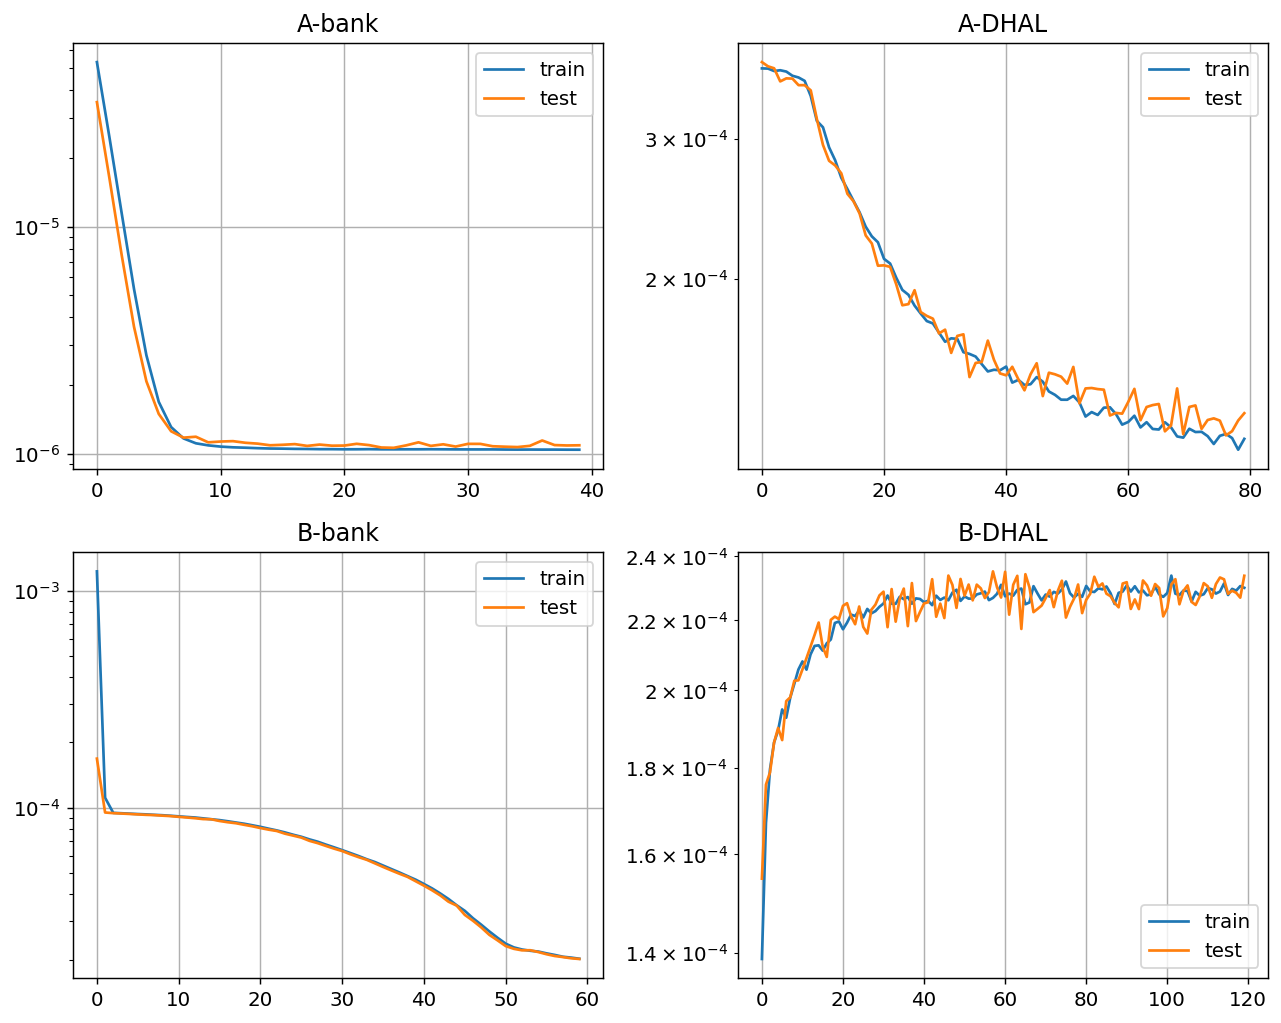

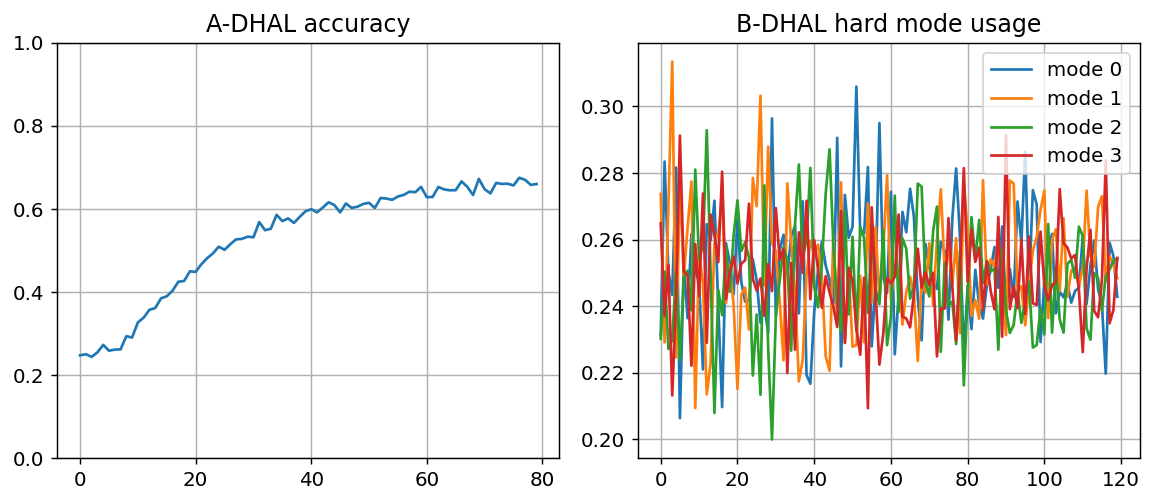

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].plot(A_bank_train, label="train")
axes[0,0].plot(A_bank_test, label="test")
axes[0,0].set_yscale("log"); axes[0,0].set_title("A-bank"); axes[0,0].legend()

axes[0,1].plot(A_sel_train, label="train")
axes[0,1].plot(A_sel_test, label="test")
axes[0,1].set_yscale("log"); axes[0,1].set_title("A-DHAL"); axes[0,1].legend()

axes[1,0].plot(B_bank_train, label="train")
axes[1,0].plot(B_bank_test, label="test")
axes[1,0].set_yscale("log"); axes[1,0].set_title("B-bank"); axes[1,0].legend()

axes[1,1].plot(B_sel_train, label="train")
axes[1,1].plot(B_sel_test, label="test")
axes[1,1].set_yscale("log"); axes[1,1].set_title("B-DHAL"); axes[1,1].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].plot(A_sel_acc)
axes[0].set_title("A-DHAL accuracy"); axes[0].set_ylim(0, 1)
usage_arr = np.array(B_sel_usage)
for k in range(usage_arr.shape[1]):
    axes[1].plot(usage_arr[:, k], label=f"mode {k}")
axes[1].set_title("B-DHAL hard mode usage"); axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Diagnostics: banks, confusion matrices, aligned evaluation

For unsupervised B-DHAL, latent labels are identifiable only up to permutation.
Aligned evaluation searches over all $4! = 24$ permutations.

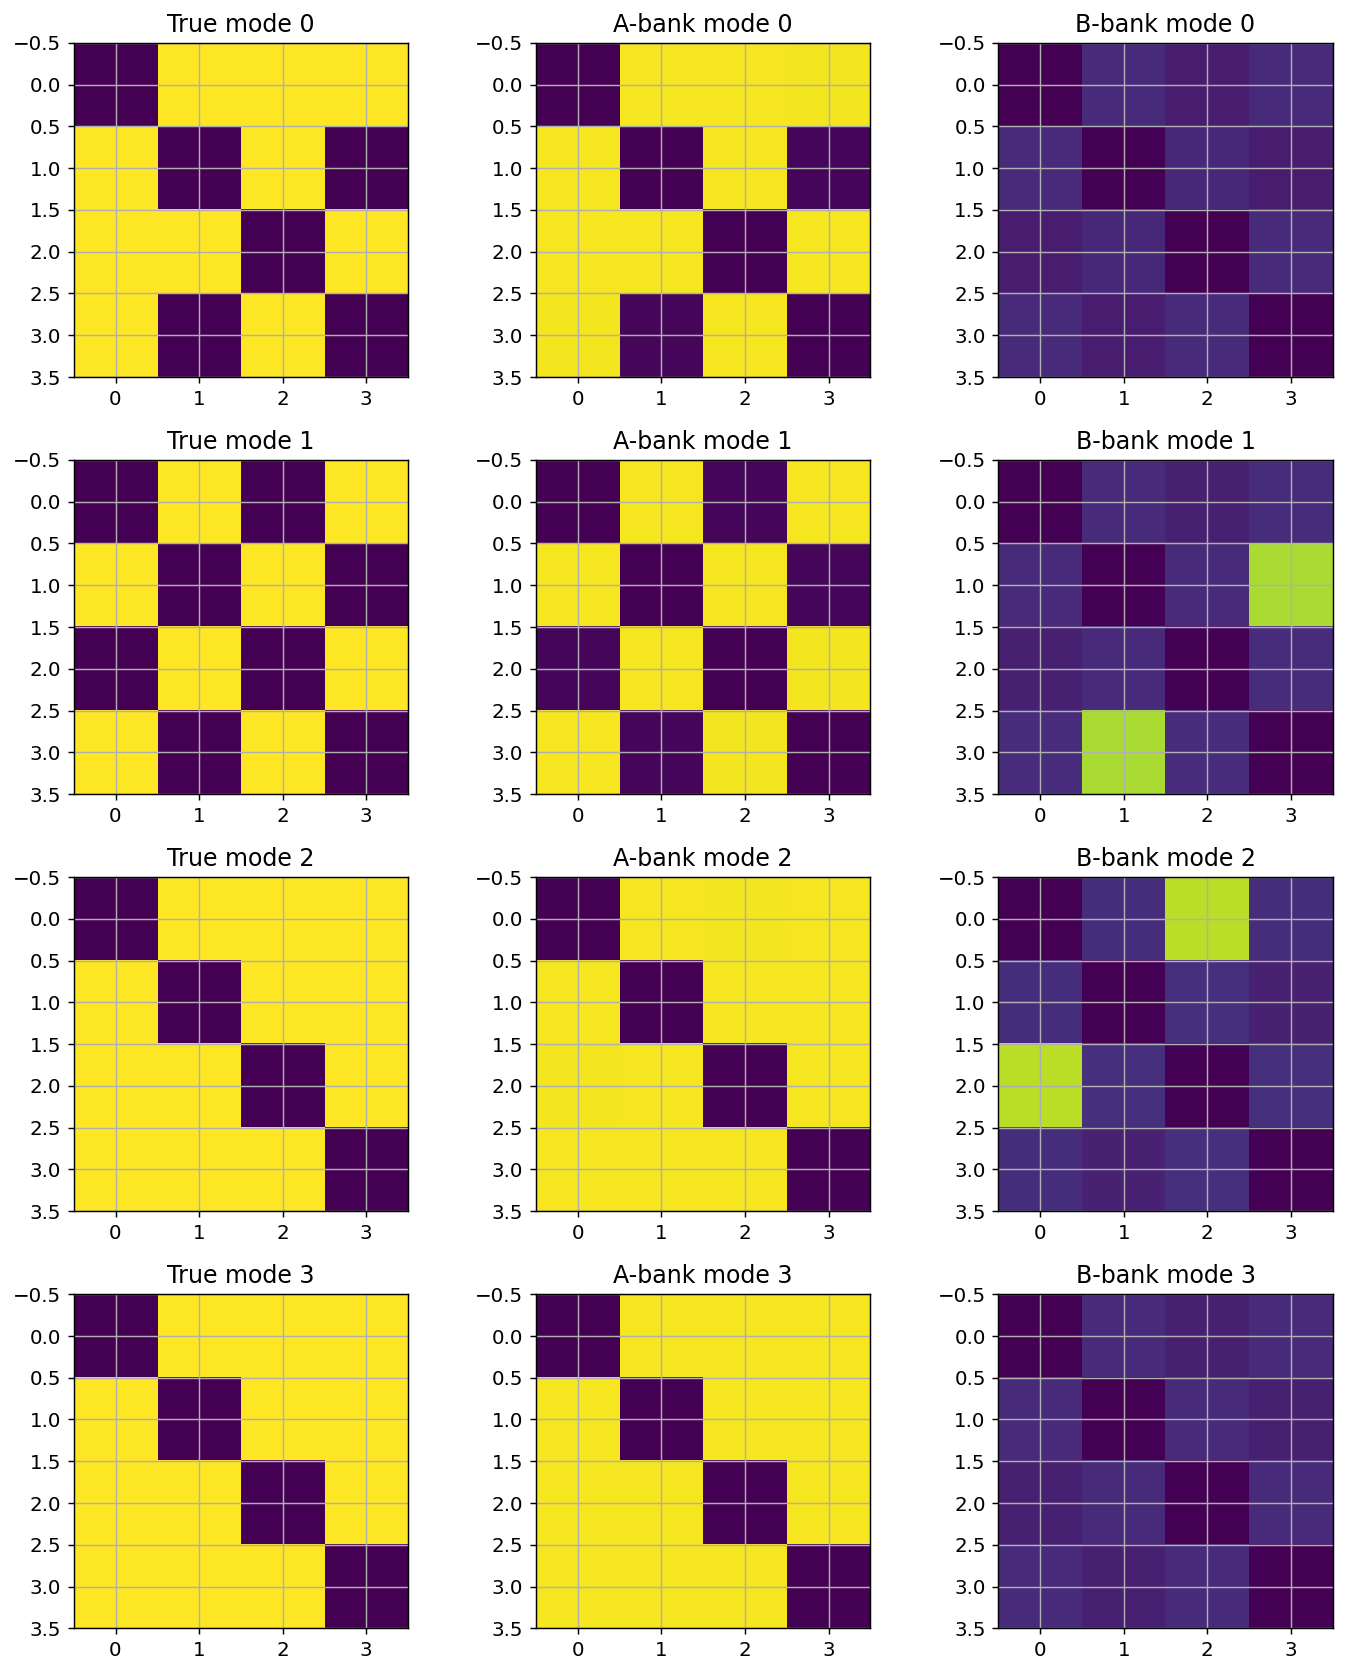

A-bank learned vs true parameters:
  Mode 0: alpha=0.0484 (0.0500), beta=-0.0498 (-0.0500), mu=[0.999 0.999 0.999 0.999] ([1. 1. 1. 1.])
         graph match: True
  Mode 1: alpha=0.0808 (0.0800), beta=-0.0399 (-0.0400), mu=[0.8   0.601 0.8   0.601] ([0.8 0.6 0.8 0.6])
         graph match: True
  Mode 2: alpha=0.0607 (0.0600), beta=-0.0600 (-0.0600), mu=[0.601 0.8   0.601 0.8  ] ([0.6 0.8 0.6 0.8])
         graph match: True
  Mode 3: alpha=0.1027 (0.1000), beta=-0.0303 (-0.0300), mu=[0.501 0.501 0.501 0.501] ([0.5 0.5 0.5 0.5])
         graph match: True


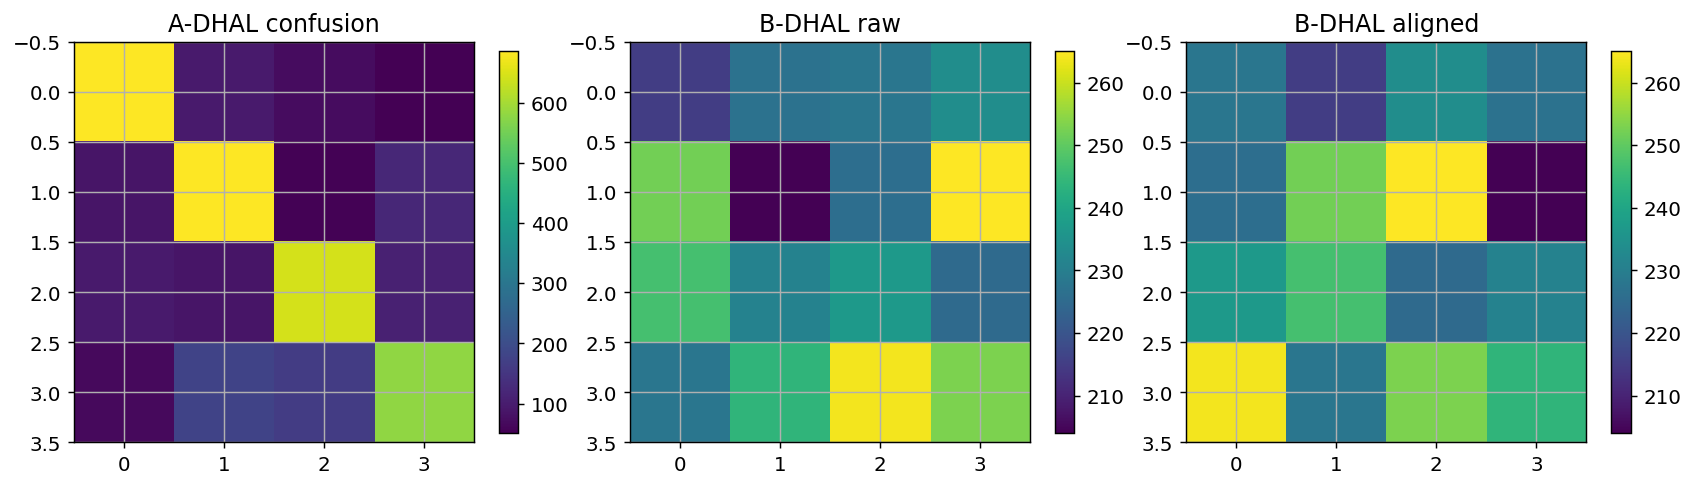

A-DHAL confusion matrix:
[[683  98  72  51]
 [ 87 685  54 121]
 [ 98  88 645 109]
 [ 67 178 164 580]]
A-DHAL accuracy: 0.6860
B-DHAL best permutation: (1, 3, 0, 2)
B-DHAL aligned confusion matrix:
[[228 215 234 227]
 [226 252 265 204]
 [237 247 225 231]
 [264 228 253 244]]
B-DHAL aligned accuracy: 0.2511


In [7]:
W_A = A_track.bank_model.bank.graphs().detach().cpu().numpy()
W_B = B_track.bank_model.bank.graphs().detach().cpu().numpy()

fig, axes = plt.subplots(4, 3, figsize=(11, 13))
for k in range(4):
    axes[k,0].imshow(true_graphs[k], vmin=0, vmax=1)
    axes[k,0].set_title(f"True mode {k}")
    axes[k,1].imshow(W_A[k], vmin=0, vmax=1)
    axes[k,1].set_title(f"A-bank mode {k}")
    axes[k,2].imshow(W_B[k], vmin=0, vmax=1)
    axes[k,2].set_title(f"B-bank mode {k}")
plt.tight_layout()
plt.show()

# ---- Learned parameter table ----
mu_A = A_track.bank_model.bank.mus().detach().cpu().numpy()
a_A  = A_track.bank_model.bank.alphas().detach().cpu().numpy()
b_A  = A_track.bank_model.bank.betas().detach().cpu().numpy()

print("A-bank learned vs true parameters:")
for r in range(num_modes):
    m = bistable_mode_params[r]
    print(f"  Mode {r}: alpha={a_A[r]:.4f} ({m['alpha']:.4f}), "
          f"beta={b_A[r]:.4f} ({m['beta']:.4f}), "
          f"mu={np.round(mu_A[r], 3)} ({m['mu']})")
    W_bin = (W_A[r] > 0.5).astype(int)
    print(f"         graph match: {np.array_equal(W_bin, m['A'].astype(int))}")

# ---- Confusion matrices ----
def confusion_matrix_numpy(y_true, y_pred, K):
    C = np.zeros((K, K), dtype=int)
    for a, b in zip(y_true, y_pred):
        C[a, b] += 1
    return C

def best_permutation_from_confusion(C):
    K = C.shape[0]
    best_perm = None; best_score = -1
    for perm in itertools.permutations(range(K)):
        score = sum(C[i, perm[i]] for i in range(K))
        if score > best_score:
            best_score = score; best_perm = perm
    return best_perm, best_score

def apply_perm(y_pred, perm):
    mapping = {old: new for old, new in enumerate(perm)}
    return np.array([mapping[y] for y in y_pred], dtype=int)

# A-DHAL confusion
A_track.eval()
yt_A, yp_A = [], []
with torch.no_grad():
    for hb, xb, yb, zb in lat_test_loader:
        hb = hb.to(device); xb = xb.to(device)
        _, _, _, idx = A_track(hb, xb, dt, tau=0.35)
        yt_A.append(zb.numpy()); yp_A.append(idx.cpu().numpy())
yt_A = np.concatenate(yt_A); yp_A = np.concatenate(yp_A)
C_A = confusion_matrix_numpy(yt_A, yp_A, num_modes)

# B-DHAL confusion
B_track.eval()
yt_B, yp_B = [], []
with torch.no_grad():
    for hb, xb, yb, zb in lat_test_loader:
        hb = hb.to(device); xb = xb.to(device)
        _, _, _, idx = B_track(hb, xb, dt, tau=0.35)
        yt_B.append(zb.numpy()); yp_B.append(idx.cpu().numpy())
yt_B = np.concatenate(yt_B); yp_B = np.concatenate(yp_B)
C_B_raw = confusion_matrix_numpy(yt_B, yp_B, num_modes)

perm_best, score_best = best_permutation_from_confusion(C_B_raw)
yp_B_aligned = apply_perm(yp_B, perm_best)
C_B_aligned = confusion_matrix_numpy(yt_B, yp_B_aligned, num_modes)
acc_B_aligned = np.trace(C_B_aligned) / C_B_aligned.sum()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
im0 = axes[0].imshow(C_A);         axes[0].set_title("A-DHAL confusion"); plt.colorbar(im0, ax=axes[0], shrink=0.8)
im1 = axes[1].imshow(C_B_raw);     axes[1].set_title("B-DHAL raw");       plt.colorbar(im1, ax=axes[1], shrink=0.8)
im2 = axes[2].imshow(C_B_aligned); axes[2].set_title("B-DHAL aligned");   plt.colorbar(im2, ax=axes[2], shrink=0.8)
plt.tight_layout(); plt.show()

print("A-DHAL confusion matrix:"); print(C_A)
print(f"A-DHAL accuracy: {np.trace(C_A) / C_A.sum():.4f}")
print(f"B-DHAL best permutation: {perm_best}")
print("B-DHAL aligned confusion matrix:"); print(C_B_aligned)
print(f"B-DHAL aligned accuracy: {acc_B_aligned:.4f}")

## 8. Rollout evaluation

Compare rollouts under:
- **True system** with a random piecewise-constant mode sequence
- **Bank + true modes**: bank dynamics driven by the same mode sequence
- **Bank + inferred modes**: bank dynamics with modes from the GRU selector

In [8]:
def rollout_bank_with_modes(bank_model, x0, z_seq):
    """Rollout bank dynamics driven by a given mode sequence."""
    traj = [x0.copy()]
    with torch.no_grad():
        xt = torch.tensor(x0[None], dtype=torch.float32, device=device)
        for z in z_seq:
            zt = torch.tensor([z], dtype=torch.long, device=device)
            xt = bank_model.forward_grouped(xt, zt, dt)
            traj.append(xt.cpu().numpy()[0].copy())
    return np.stack(traj, axis=0)

def infer_modes_selector(track_model, traj_phys, history_len, perm_map=None, tau=0.35):
    """Infer mode at each step from the true trajectory's history windows."""
    zhat_list = []
    with torch.no_grad():
        for k in range(1, traj_phys.shape[0]):
            if k < history_len:
                hist = traj_phys[:history_len]
            else:
                hist = traj_phys[k - history_len:k]
            hist_n = (hist - x_mean[None, :]) / x_std[None, :]
            xk = traj_phys[k - 1]
            hb = torch.tensor(hist_n[None], dtype=torch.float32, device=device)
            xb = torch.tensor(xk[None], dtype=torch.float32, device=device)
            _, _, _, idx = track_model(hb, xb, dt, tau=tau)
            z = int(idx.item())
            if perm_map is not None:
                z = perm_map[z]
            zhat_list.append(z)
    return np.array(zhat_list, dtype=int)

# ---- Generate rollouts ----
rng_roll = np.random.default_rng(99)
z_roll = random_switch_sequence(180, num_modes, min_dwell=8, max_dwell=20, rng=rng_roll)
x0_roll = rng_roll.uniform(-0.7, 0.7, size=4)
traj_true = simulate_hybrid_switched_trajectory(x0_roll, z_roll, dt, bistable_mode_params)

traj_A_true = rollout_bank_with_modes(A_track.bank_model, traj_true[0], z_roll)
traj_B_true = rollout_bank_with_modes(B_track.bank_model, traj_true[0], z_roll)

zhat_A = infer_modes_selector(A_track, traj_true, history_len, perm_map=None)
perm_map_B = {old: new for old, new in enumerate(perm_best)}
zhat_B = infer_modes_selector(B_track, traj_true, history_len, perm_map=perm_map_B)

traj_A_inf = rollout_bank_with_modes(A_track.bank_model, traj_true[0], zhat_A)
traj_B_inf = rollout_bank_with_modes(B_track.bank_model, traj_true[0], zhat_B)

T_common = min(len(traj_true), len(traj_A_true), len(traj_B_true),
               len(traj_A_inf), len(traj_B_inf))
traj_true_use = traj_true[:T_common]
traj_A_true = traj_A_true[:T_common]
traj_B_true = traj_B_true[:T_common]
traj_A_inf = traj_A_inf[:T_common]
traj_B_inf = traj_B_inf[:T_common]
t_roll = np.arange(T_common) * dt
z_roll_use = z_roll[:T_common - 1]
zhat_A = zhat_A[:T_common - 1]
zhat_B = zhat_B[:T_common - 1]

def rmse_traj(pred, true):
    return np.sqrt(np.mean((pred - true) ** 2, axis=1))

rmse_A_true = rmse_traj(traj_A_true, traj_true_use)
rmse_A_inf  = rmse_traj(traj_A_inf,  traj_true_use)
rmse_B_true = rmse_traj(traj_B_true, traj_true_use)
rmse_B_inf  = rmse_traj(traj_B_inf,  traj_true_use)

for name, arr in [("A true-mode", rmse_A_true), ("A inferred-mode", rmse_A_inf),
                  ("B true-mode", rmse_B_true), ("B inferred-mode", rmse_B_inf)]:
    print(f"{name}: mean={arr.mean():.6f} | final={arr[-1]:.6f} | max={arr.max():.6f}")

A true-mode: mean=0.002874 | final=0.003515 | max=0.006839
A inferred-mode: mean=0.024750 | final=0.019159 | max=0.087293
B true-mode: mean=0.055016 | final=0.058074 | max=0.117843
B inferred-mode: mean=0.055230 | final=0.062093 | max=0.122183


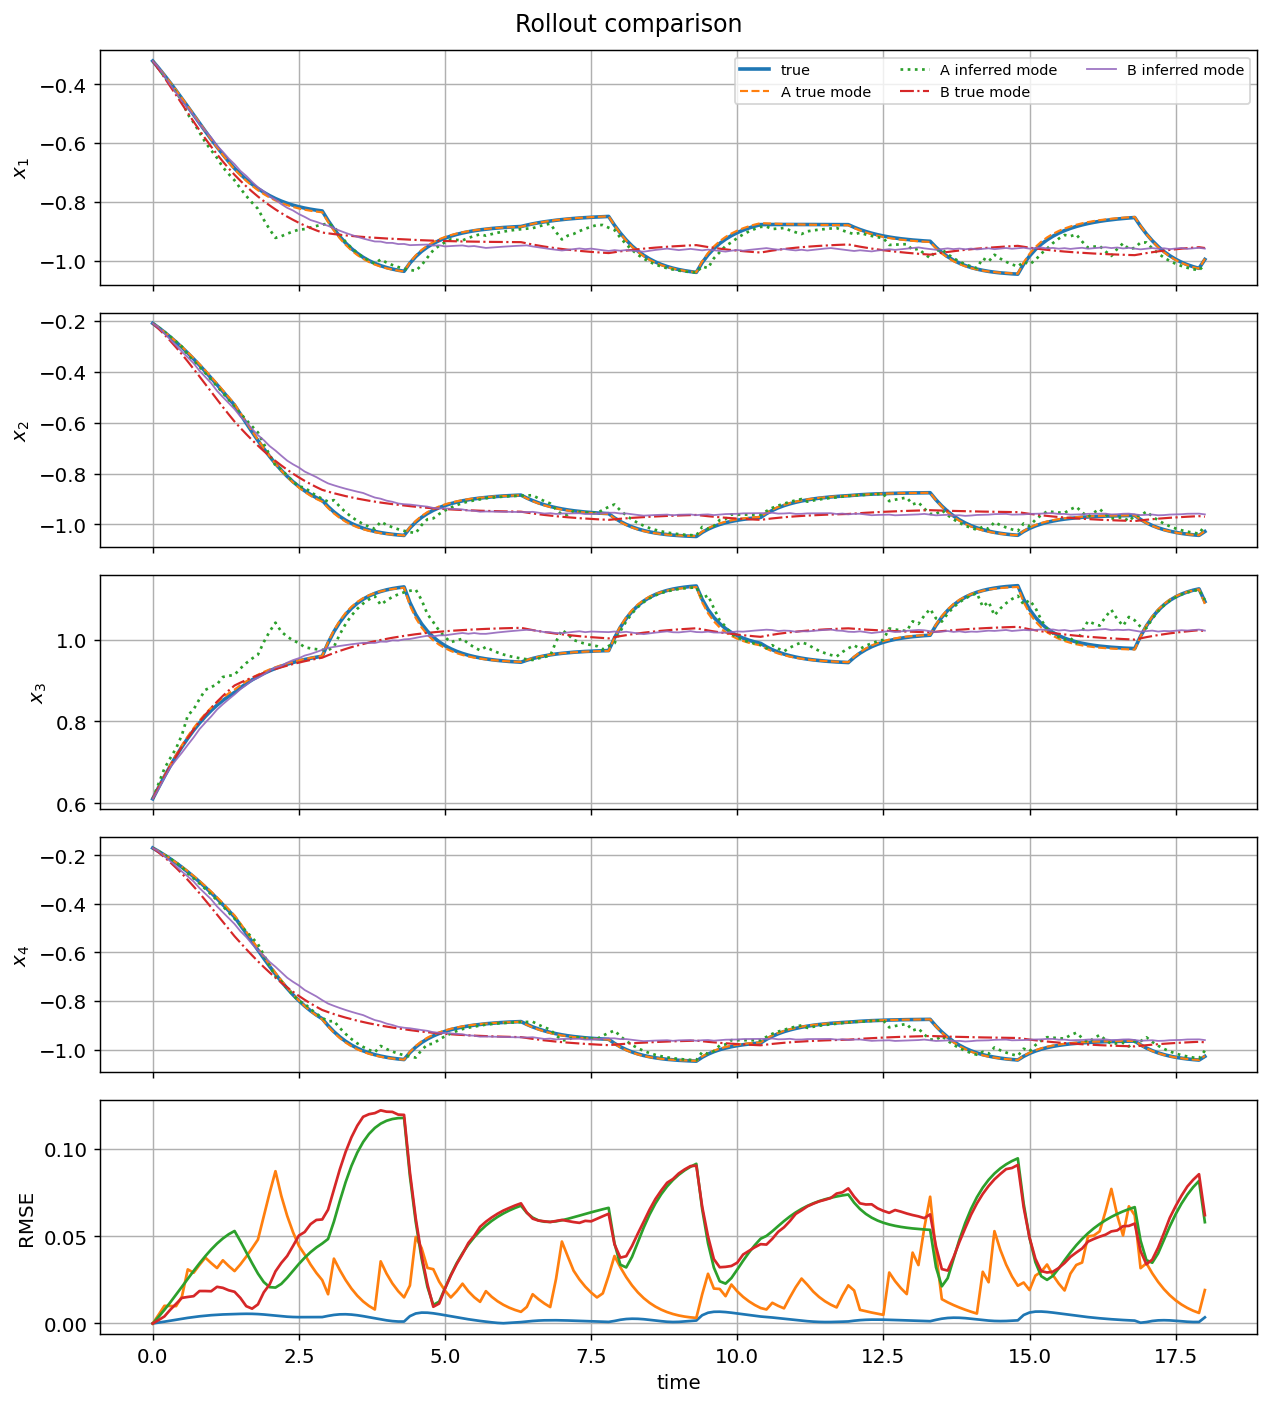

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(10, 11), sharex=True)
for i in range(4):
    axes[i].plot(t_roll, traj_true_use[:, i], linewidth=2, label="true")
    axes[i].plot(t_roll, traj_A_true[:, i], "--", linewidth=1.2, label="A true mode")
    axes[i].plot(t_roll, traj_A_inf[:, i], ":", linewidth=1.5, label="A inferred mode")
    axes[i].plot(t_roll, traj_B_true[:, i], "-.", linewidth=1.2, label="B true mode")
    axes[i].plot(t_roll, traj_B_inf[:, i], linewidth=1.0, alpha=0.9, label="B inferred mode")
    axes[i].set_ylabel(f"$x_{i+1}$")
axes[4].plot(t_roll, rmse_A_true, label="A true mode")
axes[4].plot(t_roll, rmse_A_inf, label="A inferred mode")
axes[4].plot(t_roll, rmse_B_true, label="B true mode")
axes[4].plot(t_roll, rmse_B_inf, label="B inferred mode")
axes[4].set_ylabel("RMSE")
axes[4].set_xlabel("time")
axes[0].legend(ncol=3, fontsize=8)
fig.suptitle("Rollout comparison")
plt.tight_layout()
plt.show()

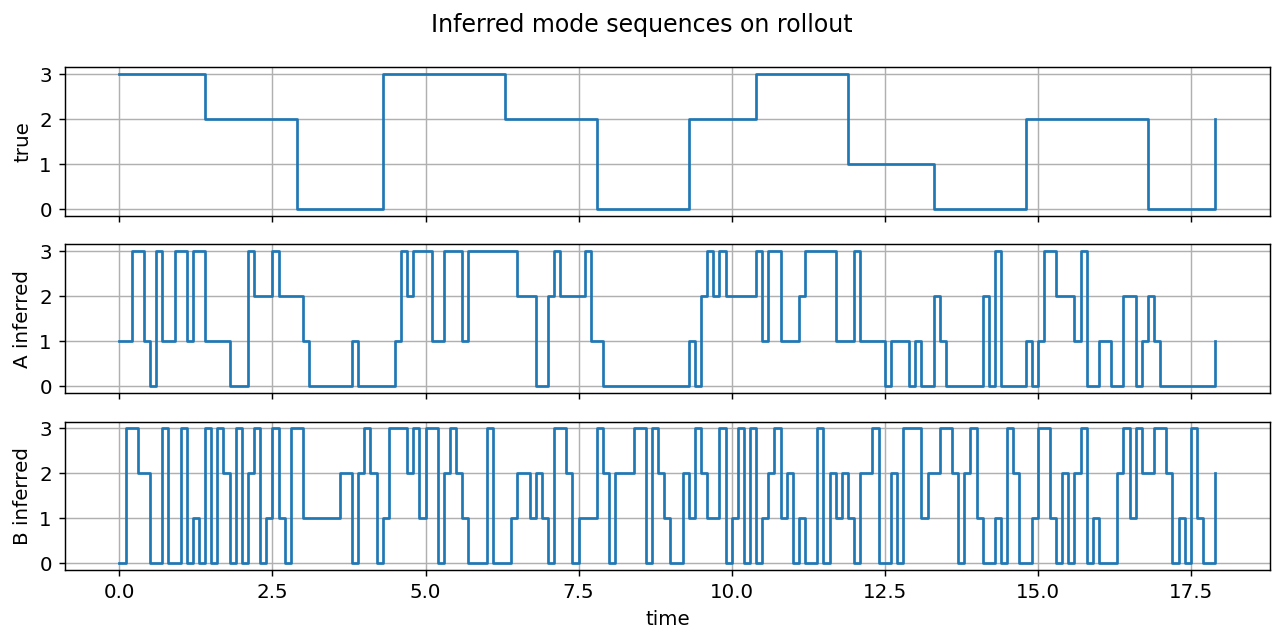

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
axes[0].step(t_roll[:-1], z_roll_use, where="post"); axes[0].set_ylabel("true")
axes[1].step(t_roll[:-1], zhat_A, where="post"); axes[1].set_ylabel("A inferred")
axes[2].step(t_roll[:-1], zhat_B, where="post"); axes[2].set_ylabel("B inferred")
axes[2].set_xlabel("time")
for ax in axes:
    ax.set_yticks(range(num_modes))
fig.suptitle("Inferred mode sequences on rollout")
plt.tight_layout()
plt.show()

## 9. Final remarks on identification

### Summary
- **A-track** remains the strong reference: the physics-informed bank recovers true graphs,
  coupling, and bifurcation parameters. The supervised selector achieves high mode accuracy.
- **B-track** is harder: prediction can be decent even when latent mode discovery is weak.
  Permutation alignment is necessary for evaluation.

### Connection to topological validation
Because the A-track learns per-mode parameters $(W^{(r)}, \mu^{(r)}, \alpha^{(r)}, \beta^{(r)})$,
we can construct a learned `SwitchingSystem` (with state-dependent polynomial guards) and compare
its **Morse graph decomposition** against the ground truth. This is done in Section 10.

Note: the identification pipeline (Sections 1--9) uses random piecewise-constant switching,
while the Morse graph analysis (Section 10) uses state-dependent switching via `SwitchingSystem`.
The per-mode dynamics are the same in both cases.

## 10. Morse graph analysis

### Goal
Compare the topological structure (Morse decomposition) of the ground-truth vs
learned (Track A) time-$\tau$ map, using the data-driven outer approximation `F_data`.

- **Ground truth**: `F_data(X_all, Y_all, grid)` -- the actual one-step transitions from the dataset.
- **Learned**: `F_data(X_all, Y_pred, grid)` -- one-step predictions from the A-bank.

With random piecewise-constant switching, the map is non-deterministic: from any state,
any of the 4 modes may fire. The outer approximation correctly captures this, which may
yield a trivially connected Morse decomposition.

In [11]:
# ---- 10.1 Grid setup ----
_data_min = X_all.min(axis=0)
_data_max = X_all.max(axis=0)
_margin   = 0.3 * (_data_max - _data_min)
_bound    = max(np.abs(_data_min - _margin).max(), np.abs(_data_max + _margin).max())
_bound    = np.ceil(_bound * 2) / 2  # round to nearest 0.5

lb_morse = np.full(4, -_bound)
ub_morse = np.full(4,  _bound)
div_morse = np.full(4, 10, dtype=int)

grid_4d = UniformGrid(bounds=np.array([lb_morse, ub_morse]), divisions=div_morse)
n_boxes = int(np.prod(div_morse))

print(f"Grid: [{lb_morse[0]}, {ub_morse[0]}]^4, {div_morse[0]}^4 = {n_boxes} boxes")
print(f"Box size: {grid_4d.box_size}")
print(f"Data points: {len(X_all)}")

Grid: [-2.0, 2.0]^4, 10^4 = 10000 boxes
Box size: [0.4 0.4 0.4 0.4]
Data points: 18900


In [12]:
# ---- 10.2 Ground-truth Morse graph (data-driven) ----
F_gt = F_data(X_all, Y_all, grid_4d, map_empty='interpolate', k_neighbors=5)

print("Computing ground-truth Morse graph from data...")
t0 = time.time()
box_map_gt, morse_graph_gt, basins_gt = full_morse_graph_analysis(grid_4d, F_gt)
t_gt = time.time() - t0

print(f"Done in {t_gt:.1f}s")
print(f"  Morse sets: {len(morse_graph_gt.nodes())}")
print(f"  Edges:      {len(morse_graph_gt.edges())}")
for i, ms in enumerate(morse_graph_gt.nodes()):
    b = len(basins_gt.get(ms, set()))
    print(f"  Set {i}: {len(ms)} boxes, basin {b} boxes")

Computing ground-truth Morse graph from data...
Done in 408.5s
  Morse sets: 1
  Edges:      0
  Set 0: 4096 boxes, basin 10000 boxes


In [13]:
# ---- 10.3 Learned Morse graph (Track A, data-driven) ----
A_track.bank_model.eval()
Y_pred_list = []
with torch.no_grad():
    for i in range(0, len(X_all), 512):
        xb = torch.tensor(X_all[i:i+512], dtype=torch.float32, device=device)
        zb = torch.tensor(Z_all[i:i+512], dtype=torch.long, device=device)
        yb = A_track.bank_model.forward_grouped(xb, zb, dt)
        Y_pred_list.append(yb.cpu().numpy())
Y_pred = np.concatenate(Y_pred_list, axis=0)

print(f"Prediction residual (vs ground truth Y): {np.sqrt(np.mean((Y_pred - Y_all)**2)):.6f}")

F_learned = F_data(X_all, Y_pred, grid_4d, map_empty='interpolate', k_neighbors=5)

print("Computing learned Morse graph...")
t0 = time.time()
box_map_l, morse_graph_l, basins_l = full_morse_graph_analysis(grid_4d, F_learned)
t_l = time.time() - t0

print(f"Done in {t_l:.1f}s")
print(f"  Morse sets: {len(morse_graph_l.nodes())}")
print(f"  Edges:      {len(morse_graph_l.edges())}")
for i, ms in enumerate(morse_graph_l.nodes()):
    b = len(basins_l.get(ms, set()))
    print(f"  Set {i}: {len(ms)} boxes, basin {b} boxes")

Prediction residual (vs ground truth Y): 0.000838
Computing learned Morse graph...
Done in 407.8s
  Morse sets: 1
  Edges:      0
  Set 0: 4096 boxes, basin 10000 boxes


In [14]:
# ---- 10.4 Quantitative comparison ----
metrics = compute_all_metrics(morse_graph_l, basins_l, morse_graph_gt, basins_gt, grid_4d)

print("=" * 65)
print("MORSE GRAPH COMPARISON: Ground Truth vs Learned (Track A)")
print("=" * 65)
print(f"{'Metric':<30} {'GT':<15} {'Learned':<15}")
print("-" * 65)
print(f"{'Morse sets':<30} {len(morse_graph_gt.nodes()):<15} {len(morse_graph_l.nodes()):<15}")
print(f"{'Edges':<30} {len(morse_graph_gt.edges()):<15} {len(morse_graph_l.edges()):<15}")
total_basin_gt = sum(len(basins_gt.get(ms, set())) for ms in morse_graph_gt.nodes())
total_basin_l  = sum(len(basins_l.get(ms, set()))  for ms in morse_graph_l.nodes())
print(f"{'Total basin boxes':<30} {total_basin_gt:<15} {total_basin_l:<15}")
print(f"{'Computation time (s)':<30} {t_gt:<15.1f} {t_l:<15.1f}")
print("-" * 65)
print(f"{'Graph isomorphic':<30} {metrics['graph']['isomorphic']}")
if metrics['graph']['edit_distance'] is not None:
    print(f"{'Graph edit distance':<30} {metrics['graph']['edit_distance']}")
print(f"{'RoA mean IoU':<30} {metrics['roa']['mean_iou']:.4f}")
print(f"{'Matched Morse sets':<30} {metrics['roa']['num_matched']}")
print("=" * 65)

MORSE GRAPH COMPARISON: Ground Truth vs Learned (Track A)
Metric                         GT              Learned        
-----------------------------------------------------------------
Morse sets                     1               1              
Edges                          0               0              
Total basin boxes              10000           10000          
Computation time (s)           408.5           407.8          
-----------------------------------------------------------------
Graph isomorphic               True
Graph edit distance            0.0
RoA mean IoU                   1.0000
Matched Morse sets             1


/var/folders/27/94st1wmd7mz9wwb7t_78xq7c0000gr/T/ipykernel_48110/2244315055.py:50: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=7, loc='best')
/var/folders/27/94st1wmd7mz9wwb7t_78xq7c0000gr/T/ipykernel_48110/2244315055.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc='best')


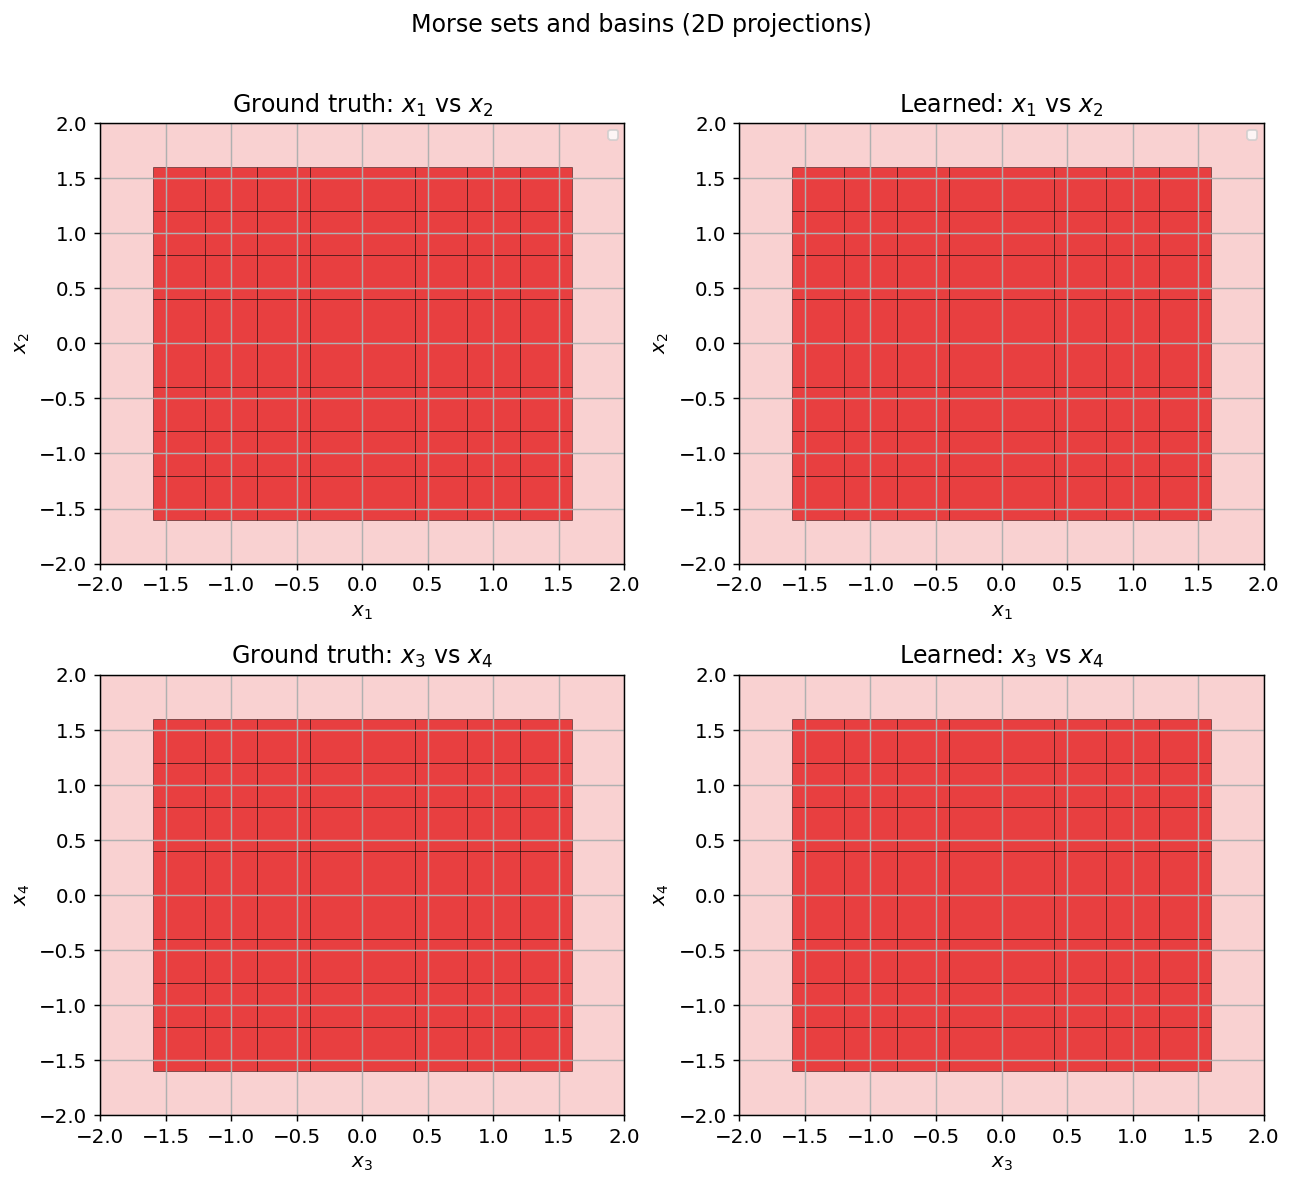

In [15]:
# ---- 10.5 Visualization: 2D projections ----
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

all_boxes_4d = grid_4d.get_boxes()  # [N, 2, 4]
proj_pairs = [(0, 1, '$x_1$', '$x_2$'), (2, 3, '$x_3$', '$x_4$')]
box_ws = [grid_4d.box_size[d] for d, _, _, _ in proj_pairs]
box_hs = [grid_4d.box_size[d] for _, d, _, _ in proj_pairs]

def projected_rectangles(box_indices, d1, d2, bw, bh):
    """Deduplicate boxes by their (d1, d2) projection and return Rectangle patches."""
    if not box_indices:
        return []
    lowers = all_boxes_4d[list(box_indices), 0, :]
    seen = set()
    rects = []
    for lo in lowers:
        key = (round(lo[d1], 10), round(lo[d2], 10))
        if key not in seen:
            seen.add(key)
            rects.append(Rectangle((lo[d1], lo[d2]), bw, bh))
    return rects

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for col, (label, mg, bas) in enumerate([("Ground truth", morse_graph_gt, basins_gt),
                                         ("Learned", morse_graph_l, basins_l)]):
    n_ms = max(len(list(mg.nodes())), 1)
    cmap_colors = plt.cm.Set1(np.linspace(0, 0.9, n_ms))
    for row, (d1, d2, xl, yl) in enumerate(proj_pairs):
        ax = axes[row, col]
        bw, bh = box_ws[row], box_hs[row]
        # Basin boxes (light filled rectangles)
        for i, ms in enumerate(mg.nodes()):
            rects = projected_rectangles(bas.get(ms, set()), d1, d2, bw, bh)
            if rects:
                pc = PatchCollection(rects, facecolor=cmap_colors[i], alpha=0.2, edgecolor='none')
                ax.add_collection(pc)
        # Morse set boxes (solid rectangles)
        for i, ms in enumerate(mg.nodes()):
            rects = projected_rectangles(ms, d1, d2, bw, bh)
            if rects:
                pc = PatchCollection(rects, facecolor=cmap_colors[i], alpha=0.8,
                                     edgecolor='k', linewidth=0.2, label=f'MS {i}')
                ax.add_collection(pc)
        ax.set_xlim(lb_morse[d1], ub_morse[d1])
        ax.set_ylim(lb_morse[d2], ub_morse[d2])
        ax.set_xlabel(xl); ax.set_ylabel(yl)
        ax.set_title(f'{label}: {xl} vs {yl}')
        ax.set_aspect('equal')
        if row == 0:
            from matplotlib.lines import Line2D
            proxies = [Line2D([0], [0], color=cmap_colors[i], lw=4, label=f'MS {i}') for i in range(n_ms)]
            ax.legend(handles=proxies, fontsize=7, loc='best')

plt.suptitle('Morse sets and basins (2D projections)', y=1.01)
plt.tight_layout()
plt.show()

## 11. Morse graph analysis via CMGDB

Repeat the Morse graph analysis using the `CMGDB` library (C++ backend with adaptive subdivision).

Two approaches:
- **Data-driven** (`BoxMapData`): outer approximation from the dataset $(X, Y)$ pairs, same data as Section 10.
- **ODE-based** (`BoxMap`): outer approximation from integrating each mode's vector field as a time-$\tau$ map.

CMGDB handles adaptive grid refinement internally (`subdiv_min` to `subdiv_max`), and provides
built-in Morse graph and Morse set visualization.

In [17]:
import CMGDB
import matplotlib

# Domain bounds (same as Section 10)
lower_bounds = lb_morse.tolist()
upper_bounds = ub_morse.tolist()

print(f"Domain: {lower_bounds} to {upper_bounds}")
print(f"Dimension: {len(lower_bounds)}")

Domain: [-2.0, -2.0, -2.0, -2.0] to [2.0, 2.0, 2.0, 2.0]
Dimension: 4


### 11.1 Data-driven Morse graph (BoxMapData)

Uses the same $(X, Y)$ dataset as Section 10. The `BoxMapData` outer approximation
handles empty boxes via interpolation.

In [ ]:
# ---- 11.1a Ground-truth (data-driven) ----
F_gt_cmgdb = CMGDB.BoxMapData(X_all, Y_all, map_empty='interp')

# subdiv_min = 20  # minimum refinement that is interesting
# subdiv_max = 24  # maximum refinement of each subdiv_min (adaptive grid procedure)
# subdiv_init = 12 # initial computation
subdiv_min = 10
subdiv_max = 10
subdiv_init = 0
subdiv_limit = 10000

model_gt = CMGDB.Model(subdiv_min, subdiv_max, subdiv_init, subdiv_limit,
                        lower_bounds, upper_bounds, F_gt_cmgdb)

print("Computing ground-truth Morse graph (CMGDB, data-driven)...")
t0 = time.time()
mg_gt_cmgdb, map_gt_cmgdb = CMGDB.ComputeMorseGraph(model_gt)
t_gt_cmgdb = time.time() - t0
print(f"Done in {t_gt_cmgdb:.1f}s, {mg_gt_cmgdb.num_vertices()} Morse sets")

Computing ground-truth Morse graph (CMGDB, data-driven)...
Done in 2.1s, 1 Morse sets


In [19]:
# ---- 11.1b Learned (data-driven) ----
F_l_cmgdb = CMGDB.BoxMapData(X_all, Y_pred, map_empty='interp')

model_l = CMGDB.Model(subdiv_min, subdiv_max, subdiv_init, subdiv_limit,
                       lower_bounds, upper_bounds, F_l_cmgdb)

print("Computing learned Morse graph (CMGDB, data-driven)...")
t0 = time.time()
mg_l_cmgdb, map_l_cmgdb = CMGDB.ComputeMorseGraph(model_l)
t_l_cmgdb = time.time() - t0
print(f"Done in {t_l_cmgdb:.1f}s, {mg_l_cmgdb.num_vertices()} Morse sets")

Computing learned Morse graph (CMGDB, data-driven)...
Done in 2.1s, 1 Morse sets


Ground truth (data-driven):


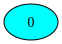

In [20]:
# ---- 11.1c Visualization (data-driven) ----
print("Ground truth (data-driven):")
CMGDB.PlotMorseGraph(mg_gt_cmgdb, cmap=matplotlib.cm.cool)

GT Morse sets (x1 vs x2):


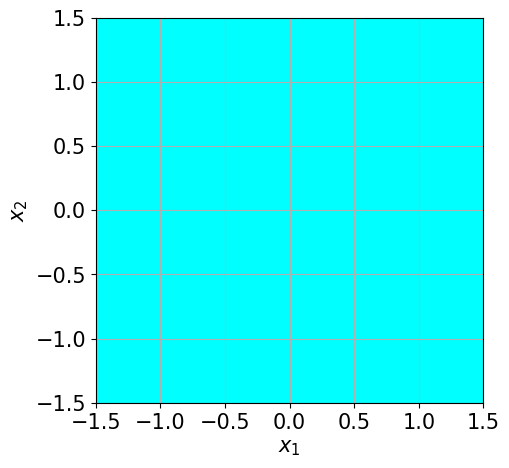

In [21]:
print("GT Morse sets (x1 vs x2):")
CMGDB.PlotMorseSets(mg_gt_cmgdb, proj_dims=[0, 1], cmap=matplotlib.cm.cool,
                    fig_w=5, fig_h=5, xlabel='$x_1$', ylabel='$x_2$')

Learned (data-driven):


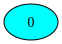

In [22]:
print("Learned (data-driven):")
CMGDB.PlotMorseGraph(mg_l_cmgdb, cmap=matplotlib.cm.cool)

Learned Morse sets (x1 vs x2):


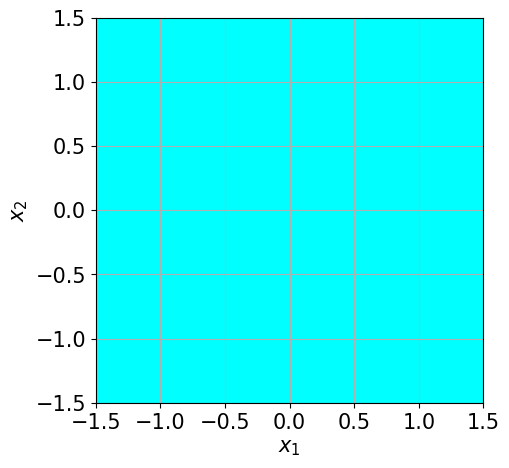

In [23]:
print("Learned Morse sets (x1 vs x2):")
CMGDB.PlotMorseSets(mg_l_cmgdb, proj_dims=[0, 1], cmap=matplotlib.cm.cool,
                    fig_w=5, fig_h=5, xlabel='$x_1$', ylabel='$x_2$')

### 11.2 ODE-based Morse graph (BoxMap)

For each mode $r$, define a time-$\tau$ map $\varphi_r(x) = x(t{+}\tau)$ by integrating mode $r$'s
vector field. Use `CMGDB.BoxMap` to build the outer approximation from the point map.

This gives a per-mode analysis (each mode's dynamics in isolation).

In [24]:
# ---- 11.2 ODE-based per-mode Morse graphs ----
tau_ode = 1.0

def make_tau_map(mode):
    """Create a time-tau point map for a given mode dict."""
    def f(x):
        sol = solve_ivp(lambda t, y: network_rhs_bistable(t, y, mode),
                        [0, tau_ode], x, method='RK45', rtol=1e-8, atol=1e-8)
        return sol.y[:, -1].tolist()
    return f

subdiv_min_ode = 10
subdiv_max_ode = 10
subdiv_init_ode = 0
subdiv_limit_ode = 10000

mg_ode = {}
for r in range(num_modes):
    mode = bistable_mode_params[r]
    f_r = make_tau_map(mode)

    def F_r(rect, _f=f_r):
        return CMGDB.BoxMap(_f, rect, padding=False)

    model_r = CMGDB.Model(subdiv_min_ode, subdiv_max_ode, subdiv_init_ode, subdiv_limit_ode,
                           lower_bounds, upper_bounds, F_r)

    print(f"Mode {r}: computing ODE-based Morse graph (tau={tau_ode})...")
    t0 = time.time()
    mg_r, map_r = CMGDB.ComputeMorseGraph(model_r)
    elapsed = time.time() - t0
    mg_ode[r] = (mg_r, map_r)
    print(f"  {mg_r.num_vertices()} Morse sets, {elapsed:.1f}s")

Mode 0: computing ODE-based Morse graph (tau=1.0)...
  323 Morse sets, 38.7s
Mode 1: computing ODE-based Morse graph (tau=1.0)...
  41 Morse sets, 12.6s
Mode 2: computing ODE-based Morse graph (tau=1.0)...
  57 Morse sets, 18.9s
Mode 3: computing ODE-based Morse graph (tau=1.0)...
  31 Morse sets, 5.7s



Mode 0 (323 Morse sets):


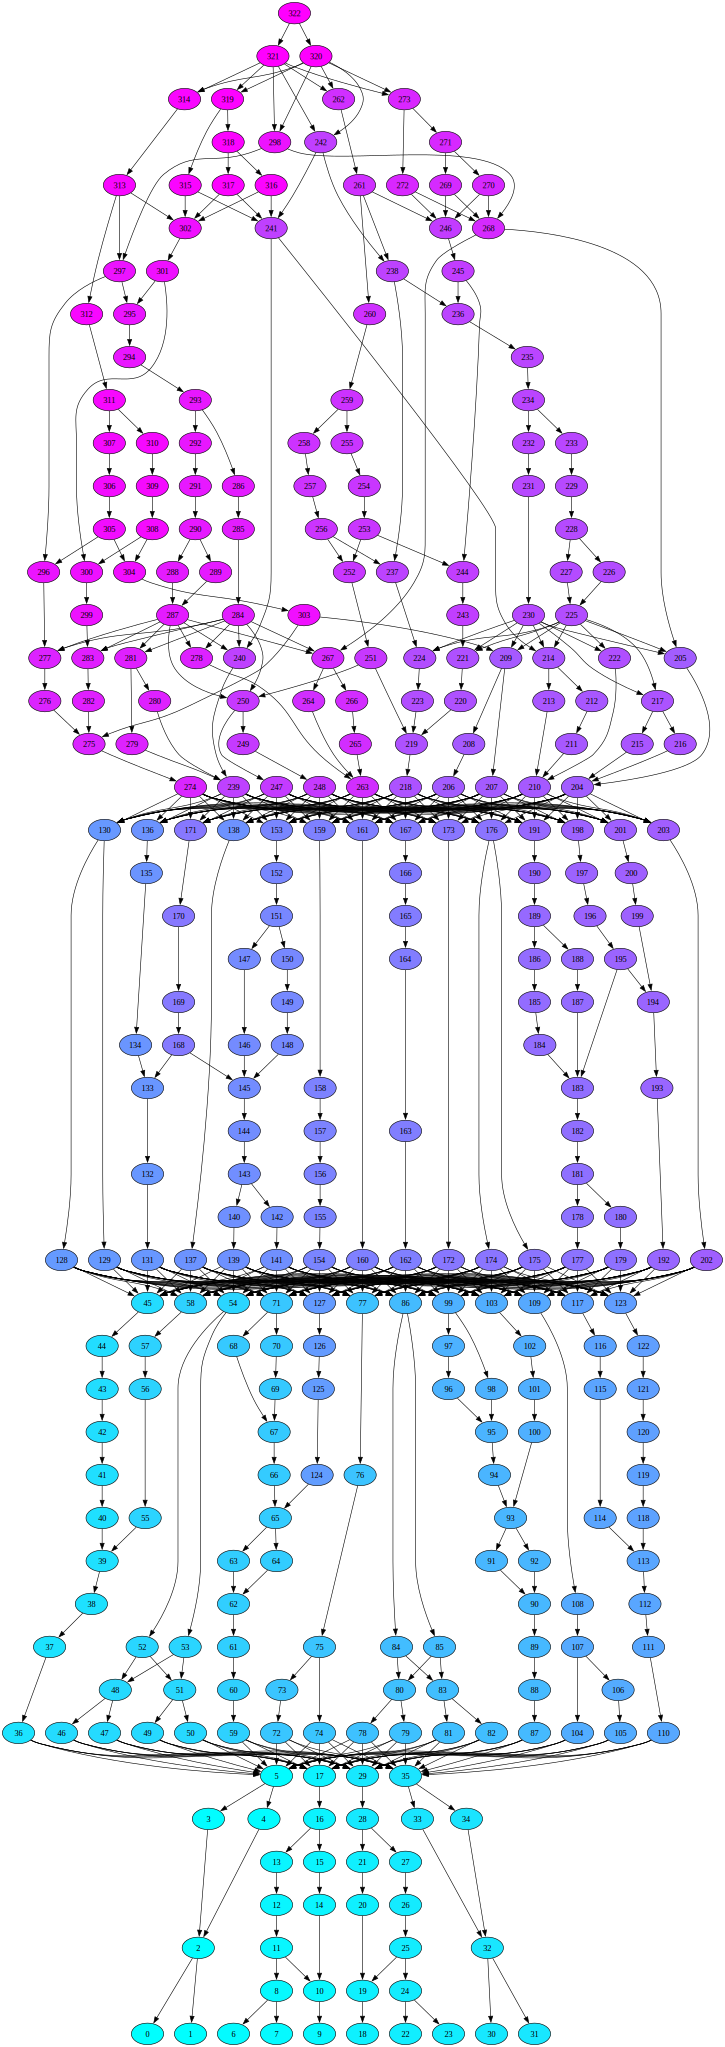

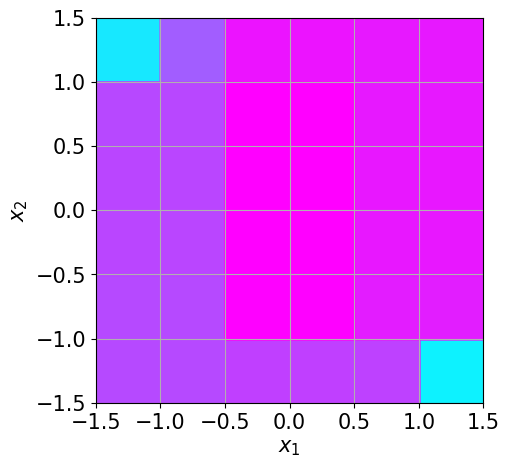


Mode 1 (41 Morse sets):


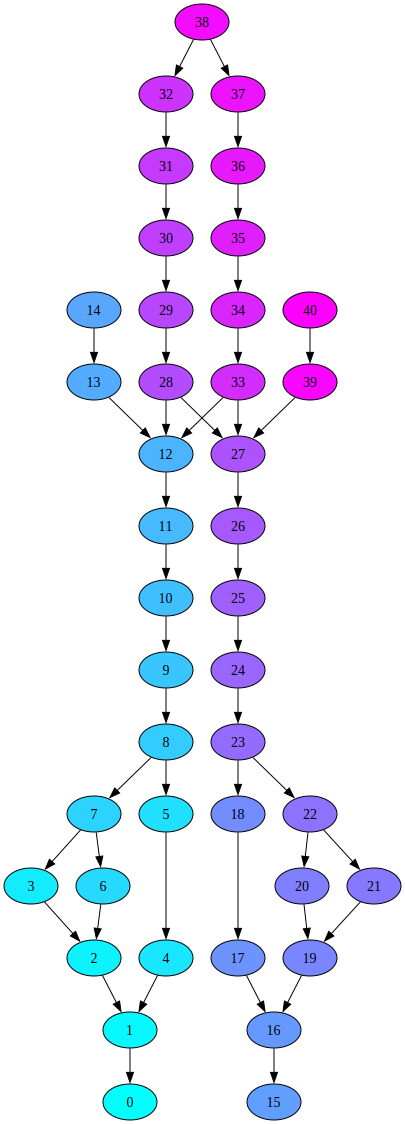

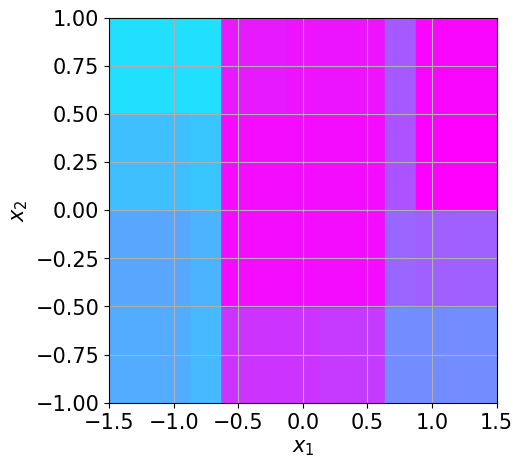


Mode 2 (57 Morse sets):


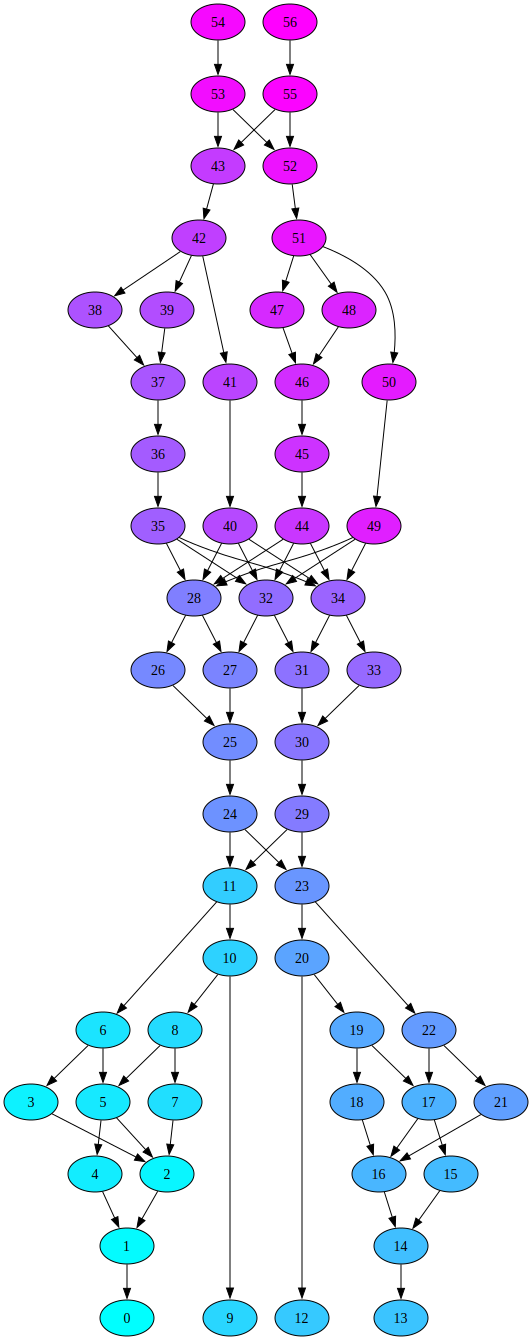

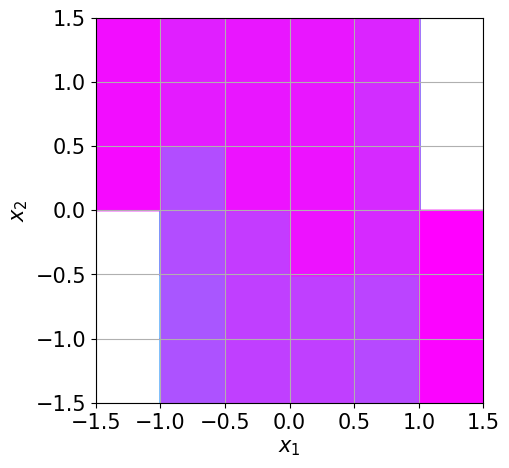


Mode 3 (31 Morse sets):


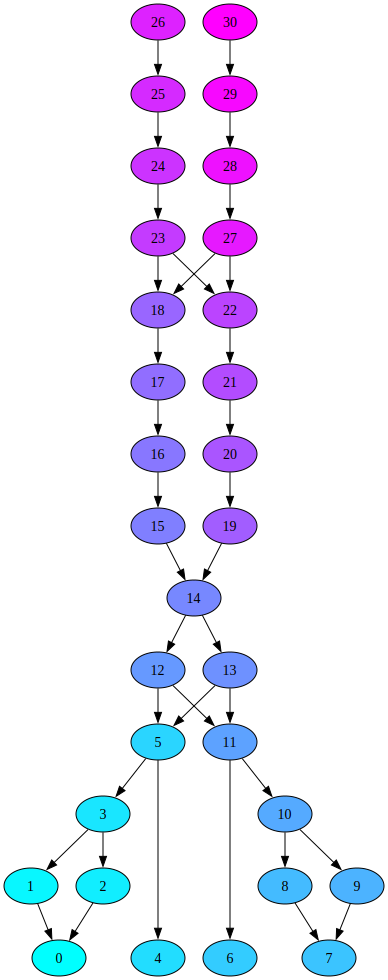

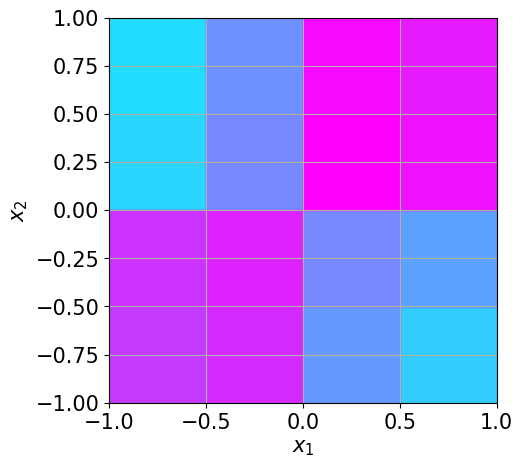

In [25]:
# ---- 11.2 Visualization: per-mode ODE Morse graphs ----
for r in range(num_modes):
    mg_r, _ = mg_ode[r]
    print(f"\nMode {r} ({mg_r.num_vertices()} Morse sets):")
    display(CMGDB.PlotMorseGraph(mg_r, cmap=matplotlib.cm.cool))
    CMGDB.PlotMorseSets(mg_r, proj_dims=[0, 1], cmap=matplotlib.cm.cool,
                        fig_w=5, fig_h=5, xlabel='$x_1$', ylabel='$x_2$')